# EuroSAT Land Use Classification

**Lauren Choi & Chloe Robinson**

April 5, 2026

## Overview

| Section | Description | Classes |
|---------|-------------|---------|
| 1. Data Processing | Download, explore, preprocess EuroSAT | All 10 |
| 2. Traditional ML | SVM (binary & multiclass), Random Forest | 3 (Forest, Residential, Industrial) |
| 3. Deep Learning | Fully-connected, CNN, Transfer Learning | All 10 |
| 4. Analysis | Model comparison, insights, future work | — |

---


In [1]:
# =============================================================================
# Imports & Global Configuration
# =============================================================================
import copy
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

warnings.filterwarnings("ignore")

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Plot style ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# --- Device ---
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")


Using device: mps


---

# 1. Data Processing & Exploration

The **EuroSAT** dataset contains 27,000 Sentinel-2 satellite image patches (64×64 pixels) across 10 land use/land cover classes. Each patch is available in both RGB (3 channels) and multispectral (13 channels) formats.

**Classes:** AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake

## 1.1 Download the Dataset

In [2]:
# =============================================================================
# 1.1 Download the EuroSAT RGB dataset via torchvision
# =============================================================================
# torchvision provides a convenient wrapper for the EuroSAT dataset.
# We download it into a local `data/` directory (excluded from git via .gitignore).

DATA_DIR = "data"

# Download with no transform first — we'll apply transforms later
full_dataset = datasets.EuroSAT(root=DATA_DIR, download=True)

# Class names are stored as an attribute
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Total samples : {len(full_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Classes : {class_names}")
print(f"Image shape : {np.array(full_dataset[0][0]).shape}")

Total samples : 27000
Number of classes: 10
Classes : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape : (64, 64, 3)


## 1.2 Exploratory Data Analysis (EDA)


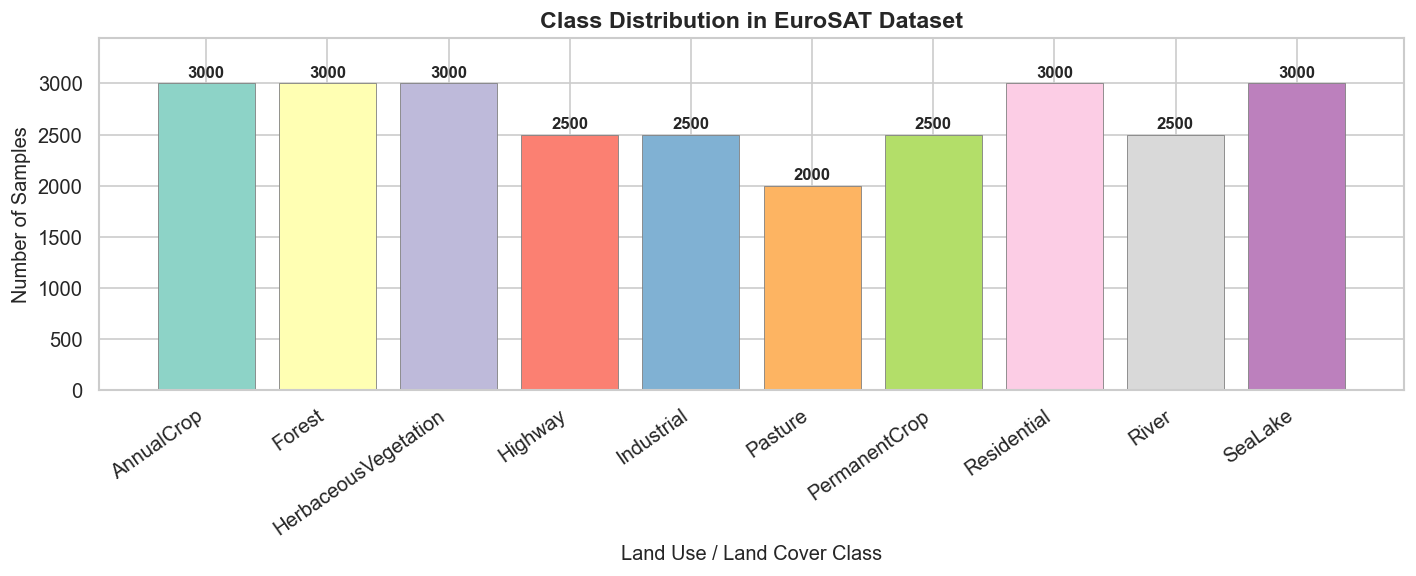

Min class: Pasture (2000)
Max class: AnnualCrop (3000)
Imbalance ratio: 1.50x


In [3]:
# =============================================================================
# 1.2a Class Distribution
# =============================================================================
# Count the number of samples per class to check for imbalance.

labels = [label for _, label in full_dataset]
label_counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("Set3", num_classes)
bars = ax.bar(class_names, label_counts, color=colors, edgecolor="gray", linewidth=0.5)

# Add count annotations on top of each bar
for bar, count in zip(bars, label_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Class Distribution in EuroSAT Dataset", fontweight="bold")
ax.set_xlabel("Land Use / Land Cover Class")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, max(label_counts) * 1.15)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print(f"\
Min class: {class_names[np.argmin(label_counts)]} ({label_counts.min()})")
print(f"Max class: {class_names[np.argmax(label_counts)]} ({label_counts.max()})")
print(f"Imbalance ratio: {label_counts.max() / label_counts.min():.2f}x")

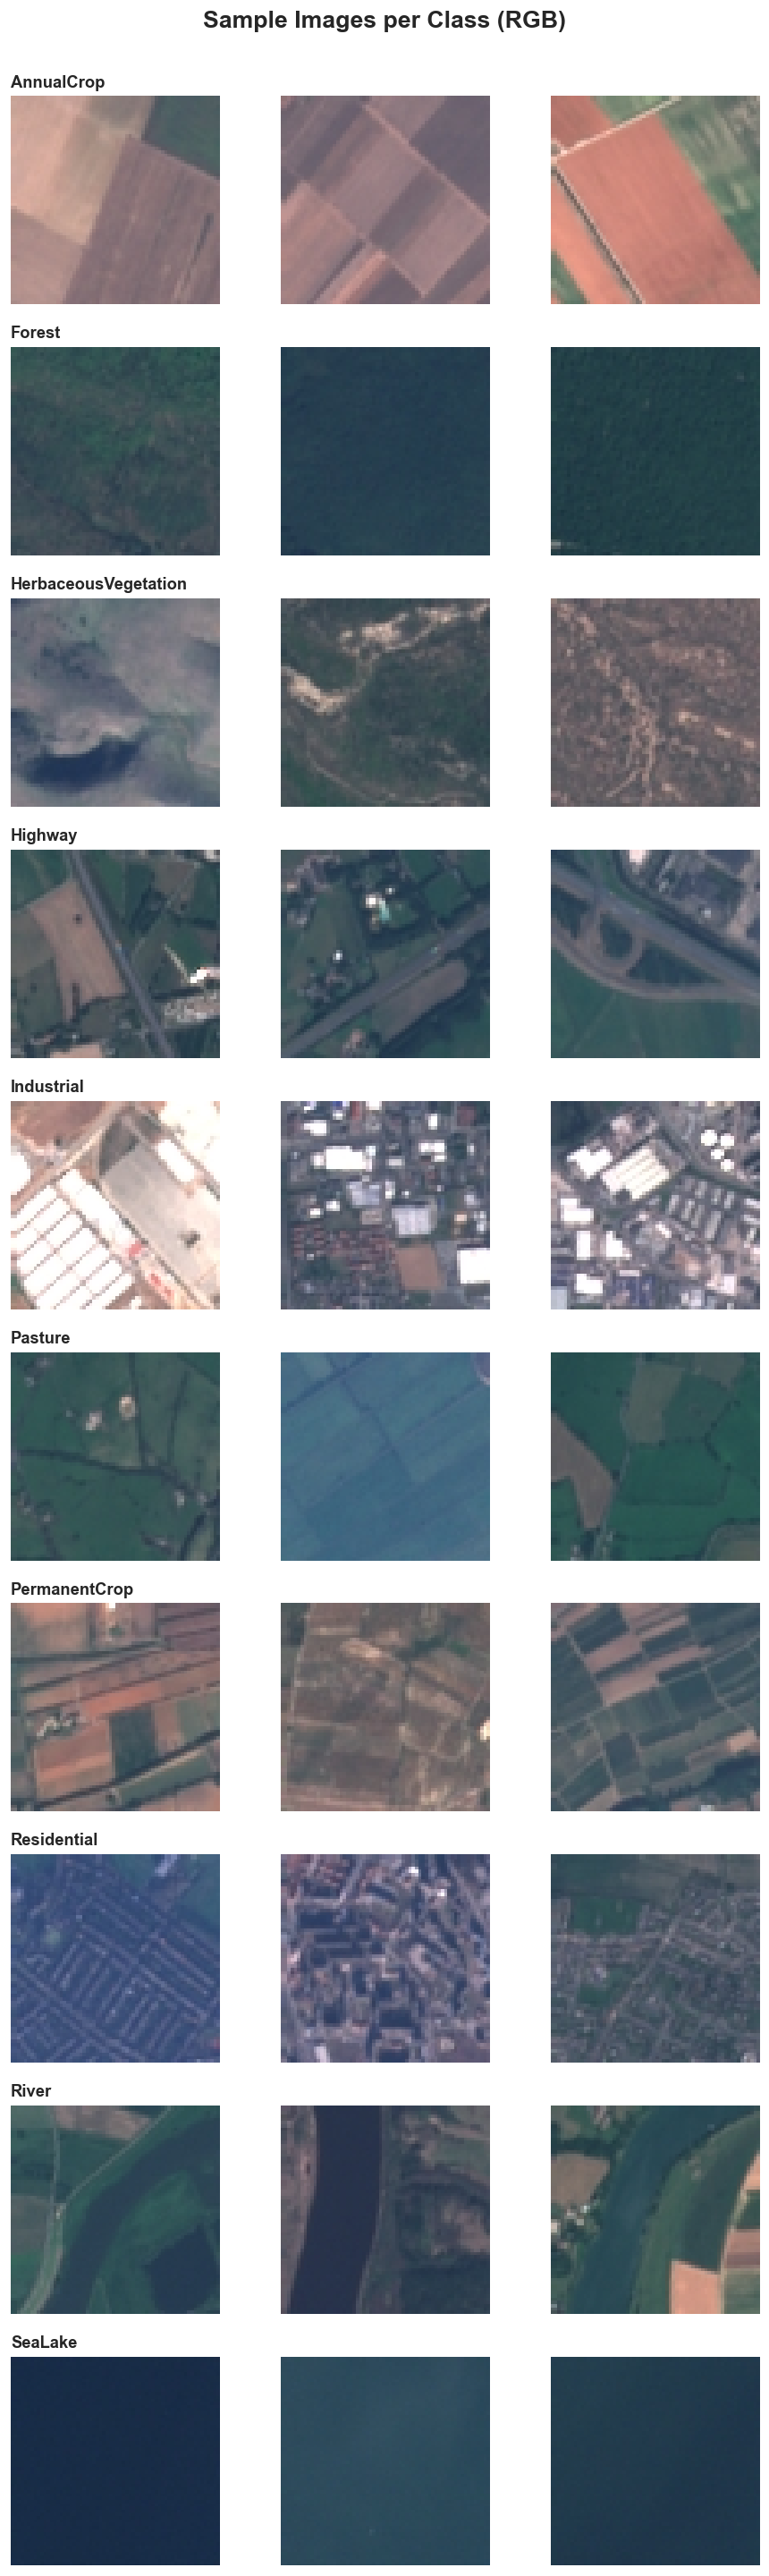

In [4]:
# =============================================================================
# 1.2b Sample Images from Each Class
# =============================================================================
# Visualize 3 random samples per class to get a feel for the visual diversity.

fig, axes = plt.subplots(num_classes, 3, figsize=(8, 24))

# Group dataset indices by class
class_indices = {c: [] for c in range(num_classes)}
for idx, (_, label) in enumerate(full_dataset):
    class_indices[label].append(idx)

for row, cls in enumerate(range(num_classes)):
    # Pick 3 random samples from this class
    sample_idxs = random.sample(class_indices[cls], 3)
    for col, idx in enumerate(sample_idxs):
        img, _ = full_dataset[idx]
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(class_names[cls], fontsize=11, fontweight="bold", loc="left")

plt.suptitle("Sample Images per Class (RGB)", fontsize=16, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## 1.3 Data Preprocessing

We need to prepare data in several formats for different model types:

1. **RGB tensors** (64×64×3) — for CNN / deep learning models
2. **Grayscale tensors** (64×64×1) — for fully-connected deep learning models
3. **Flattened 2D matrix** (n_samples × p_pixels) — for traditional ML (SVM, Random Forest)

All data is split with **stratified 60% train / 20% validation / 20% test** partitions.
The validation split is used for model selection and training diagnostics, while the test split is held out for final evaluation.


In [5]:
# =============================================================================
# 1.3a Load all images into numpy arrays
# =============================================================================
# Convert all PIL images to numpy arrays for flexible preprocessing.
# This step loads everything into memory — feasible since EuroSAT is ~2.5 GB uncompressed.

print("Loading all images into memory...")

all_images_rgb = []  # (N, 64, 64, 3) uint8
all_labels = []

for img, label in tqdm(full_dataset, desc="Loading images"):
    all_images_rgb.append(np.array(img))
    all_labels.append(label)

all_images_rgb = np.array(all_images_rgb)  # shape: (N, 64, 64, 3)
all_labels = np.array(all_labels)           # shape: (N,)

print(f"\
RGB images shape : {all_images_rgb.shape}")
print(f"Labels shape     : {all_labels.shape}")
print(f"Pixel value range: [{all_images_rgb.min()}, {all_images_rgb.max()}]")

Loading all images into memory...


Loading images: 100%|██████████| 27000/27000 [00:01<00:00, 15087.79it/s]


RGB images shape : (27000, 64, 64, 3)
Labels shape     : (27000,)
Pixel value range: [0, 255]


Grayscale images shape: (27000, 64, 64)


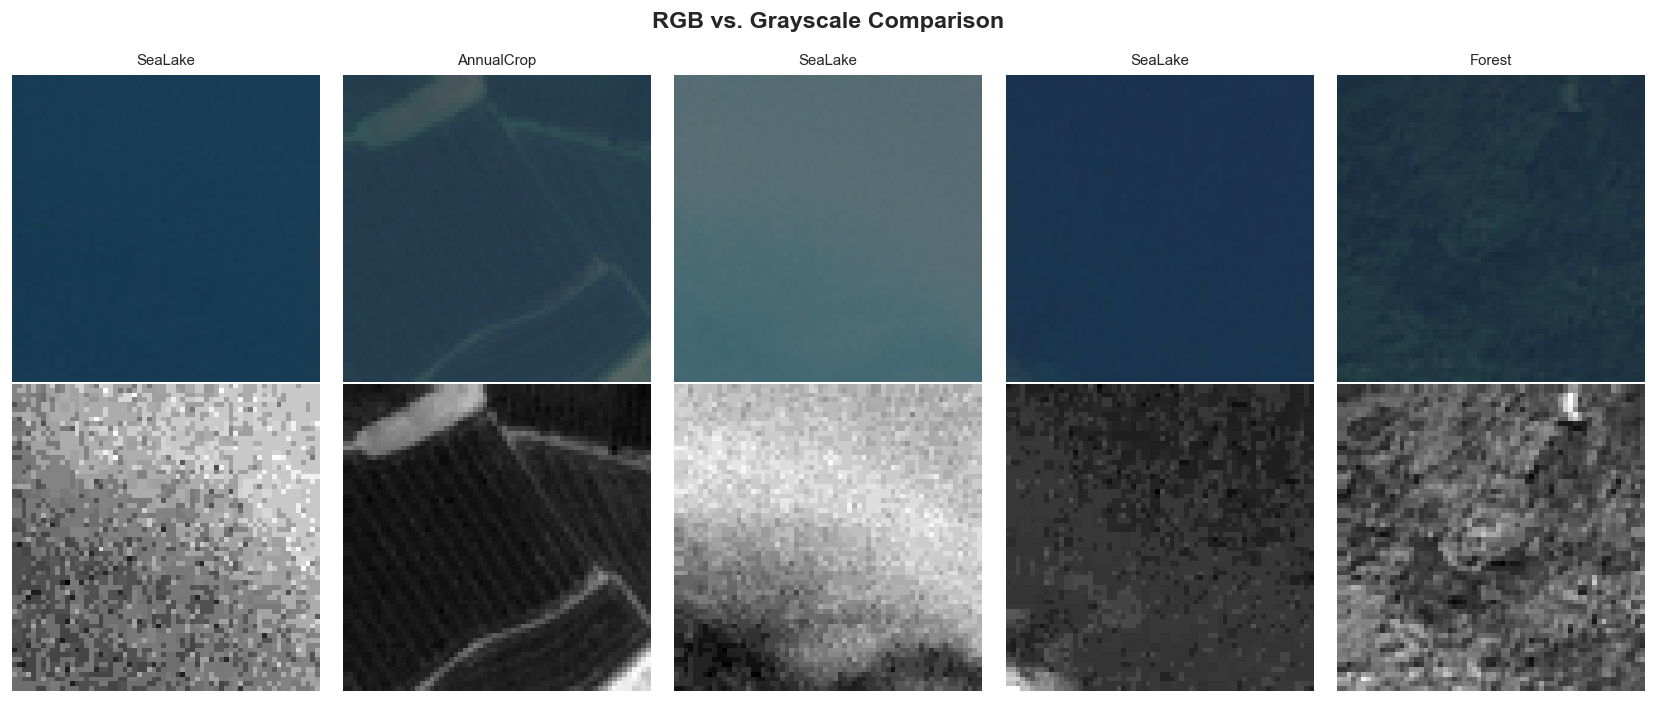

In [6]:
# =============================================================================
# 1.3b Create grayscale version
# =============================================================================
# Convert RGB to grayscale using the luminosity method:
#   Gray = 0.2989*R + 0.5870*G + 0.1140*B
# This produces a single-channel intensity image that preserves perceived brightness.

all_images_gray = np.dot(all_images_rgb[..., :3], [0.2989, 0.5870, 0.1140])
all_images_gray = all_images_gray.astype(np.float32)  # shape: (N, 64, 64)

print(f"Grayscale images shape: {all_images_gray.shape}")

# Visualize RGB vs grayscale comparison for a sample image
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    sample_idx = random.choice(range(len(all_images_rgb)))
    axes[0, i].imshow(all_images_rgb[sample_idx])
    axes[0, i].set_title(class_names[all_labels[sample_idx]], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(all_images_gray[sample_idx], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("RGB", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Grayscale", fontsize=12, fontweight="bold")
plt.suptitle("RGB vs. Grayscale Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Flattened RGB shape      : (27000, 12288)
Flattened Grayscale shape: (27000, 4096)

Train set      : 16200 samples (60%)
Validation set : 5400 samples (20%)
Test set       : 5400 samples (20%)


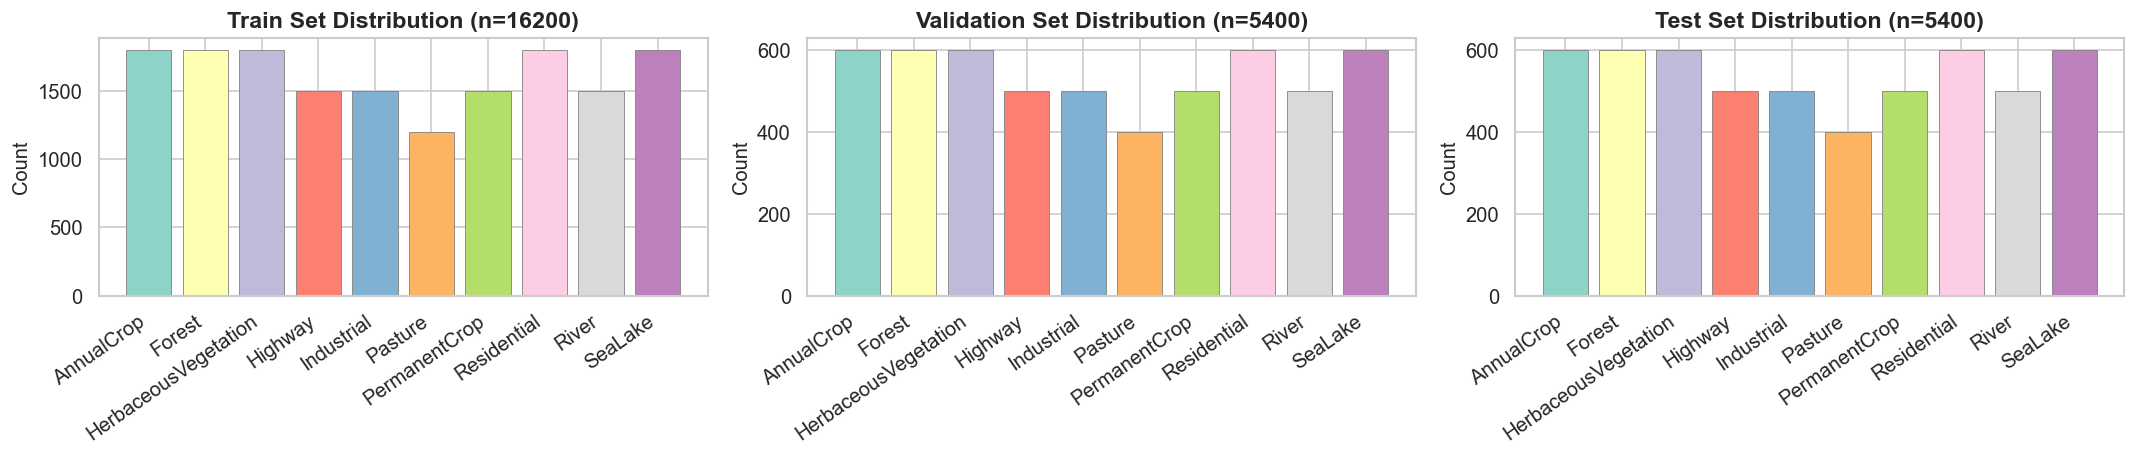

In [7]:
# =============================================================================
# 1.3c Flatten to 2D matrix & Train/Validation/Test Split
# =============================================================================
# For traditional ML models, we flatten each image into a 1D feature vector:
#   - Grayscale: 64*64 = 4,096 features per sample
#   - RGB: 64*64*3 = 12,288 features per sample
#
# We use a stratified 60/20/20 split so class proportions are preserved across
# train, validation, and test partitions.

# Normalize pixel values to [0, 1]
rgb_normalized = all_images_rgb.astype(np.float32) / 255.0
gray_normalized = all_images_gray / 255.0

# Flatten: (N, 64, 64, 3) -> (N, 12288) and (N, 64, 64) -> (N, 4096)
X_rgb_flat = rgb_normalized.reshape(len(rgb_normalized), -1)
X_gray_flat = gray_normalized.reshape(len(gray_normalized), -1)

print(f"Flattened RGB shape      : {X_rgb_flat.shape}")
print(f"Flattened Grayscale shape: {X_gray_flat.shape}")

all_indices = np.arange(len(all_labels))

idx_train, idx_temp = train_test_split(
    all_indices,
    test_size=0.4,
    random_state=SEED,
    stratify=all_labels,
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=all_labels[idx_temp],
)

X_rgb_train, X_rgb_val, X_rgb_test = X_rgb_flat[idx_train], X_rgb_flat[idx_val], X_rgb_flat[idx_test]
X_gray_train, X_gray_val, X_gray_test = X_gray_flat[idx_train], X_gray_flat[idx_val], X_gray_flat[idx_test]

y_train, y_val, y_test = all_labels[idx_train], all_labels[idx_val], all_labels[idx_test]

print(f"\nTrain set      : {len(y_train)} samples ({len(y_train)/len(all_labels)*100:.0f}%)")
print(f"Validation set : {len(y_val)} samples ({len(y_val)/len(all_labels)*100:.0f}%)")
print(f"Test set       : {len(y_test)} samples ({len(y_test)/len(all_labels)*100:.0f}%)")

# Verify stratification
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (y, title) in zip(
    axes,
    [(y_train, "Train"), (y_val, "Validation"), (y_test, "Test")],
):
    counts = np.bincount(y, minlength=num_classes)
    ax.bar(class_names, counts, color=colors, edgecolor="gray", linewidth=0.5)
    ax.set_title(f"{title} Set Distribution (n={len(y)})", fontweight="bold")
    ax.set_ylabel("Count")
    plt.sca(ax)
    plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 1.4 Prepare PyTorch Tensors and Datasets for Deep Learning


In [8]:
# =============================================================================
# 1.4 Prepare PyTorch tensors and base datasets
# =============================================================================
# For CNNs, PyTorch expects (N, C, H, W) tensors.

BATCH_SIZE = 64


def to_nchw_tensor(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)


class TensorImageDataset(Dataset):
    """Dataset wrapper that applies torchvision transforms to CHW tensors."""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].clone()
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


# --- RGB tensors (N, 3, 64, 64) ---
X_rgb_train_tensor = to_nchw_tensor(rgb_normalized[idx_train])
X_rgb_val_tensor = to_nchw_tensor(rgb_normalized[idx_val])
X_rgb_test_tensor = to_nchw_tensor(rgb_normalized[idx_test])

# --- Grayscale image tensors (N, 1, 64, 64) ---
X_gray_train_tensor = torch.tensor(gray_normalized[idx_train][:, np.newaxis, :, :], dtype=torch.float32)
X_gray_val_tensor = torch.tensor(gray_normalized[idx_val][:, np.newaxis, :, :], dtype=torch.float32)
X_gray_test_tensor = torch.tensor(gray_normalized[idx_test][:, np.newaxis, :, :], dtype=torch.float32)

# --- Flattened grayscale tensors for FC networks ---
X_gray_train_flat_tensor = torch.tensor(X_gray_train, dtype=torch.float32)
X_gray_val_flat_tensor = torch.tensor(X_gray_val, dtype=torch.float32)
X_gray_test_flat_tensor = torch.tensor(X_gray_test, dtype=torch.float32)

# --- Label tensors ---
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Base datasets / loaders ---
plain_rgb_train_dataset = TensorImageDataset(X_rgb_train_tensor, y_train_tensor)
plain_rgb_val_dataset = TensorImageDataset(X_rgb_val_tensor, y_val_tensor)
plain_rgb_test_dataset = TensorImageDataset(X_rgb_test_tensor, y_test_tensor)

train_gray_loader = DataLoader(
    TensorDataset(X_gray_train_flat_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_gray_loader = DataLoader(
    TensorDataset(X_gray_val_flat_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_gray_loader = DataLoader(
    TensorDataset(X_gray_test_flat_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"RGB train tensor        : {X_rgb_train_tensor.shape}")
print(f"RGB validation tensor   : {X_rgb_val_tensor.shape}")
print(f"Gray image train tensor : {X_gray_train_tensor.shape}")
print(f"Gray flat train tensor  : {X_gray_train_flat_tensor.shape}")
print(f"Train gray batches      : {len(train_gray_loader)}")


RGB train tensor        : torch.Size([16200, 3, 64, 64])
RGB validation tensor   : torch.Size([5400, 3, 64, 64])
Gray image train tensor : torch.Size([16200, 1, 64, 64])
Gray flat train tensor  : torch.Size([16200, 4096])
Train gray batches      : 254


## 1.5 Data Augmentation

Data augmentation is applied **only to the training split** for image-based deep learning models.


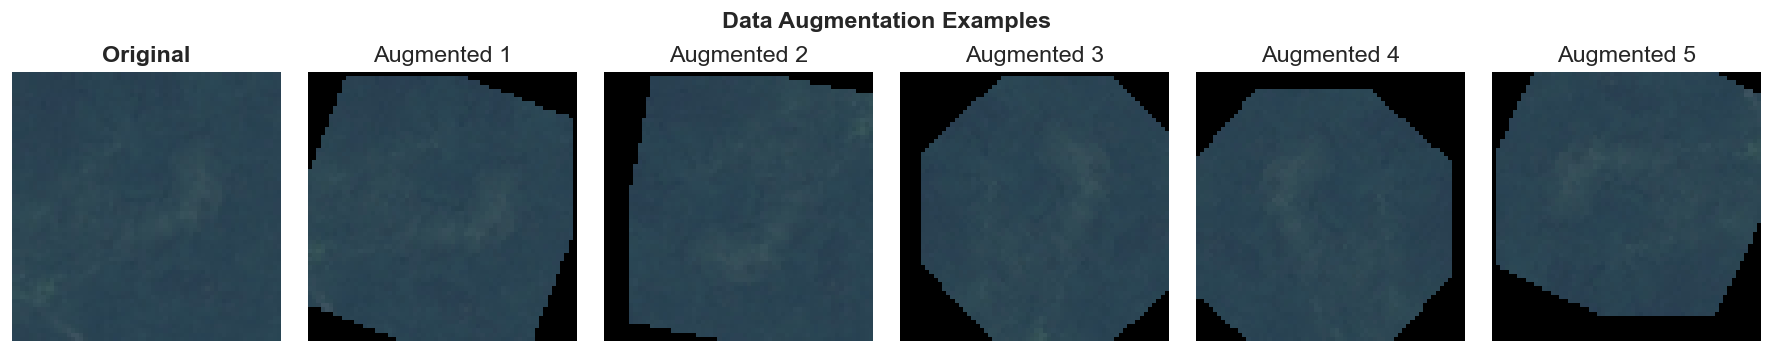

Note: RGB and ResNet training datasets now apply augmentation on-the-fly.


In [9]:
# =============================================================================
# 1.5 Data Augmentation (applied only to training image datasets)
# =============================================================================

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
])

train_rgb_dataset = TensorImageDataset(X_rgb_train_tensor, y_train_tensor, transform=train_transform)
val_rgb_dataset = TensorImageDataset(X_rgb_val_tensor, y_val_tensor)
test_rgb_dataset = TensorImageDataset(X_rgb_test_tensor, y_test_tensor)

train_rgb_loader = DataLoader(train_rgb_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_rgb_loader = DataLoader(val_rgb_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_loader = DataLoader(test_rgb_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Demonstrate augmentation on a sample image
sample_img = X_rgb_train_tensor[0]  # (3, 64, 64)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

for i in range(1, 6):
    augmented = train_transform(sample_img)
    axes[i].imshow(augmented.permute(1, 2, 0).numpy())
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Note: RGB and ResNet training datasets now apply augmentation on-the-fly.")


---

# 2. Traditional Machine Learning

In this section, we apply classical ML algorithms to a **3-class subset** of EuroSAT:
- **Forest** (class index 1)
- **Industrial** (class index 4)
- **Residential** (class index 7)

We use the **flattened grayscale** feature vectors (4,096 dimensions) as input.

## Approach
1. **Binary SVMs** — Three one-vs-one classifiers with linear kernels
2. **Multiclass SVM** — Majority-vote ensemble of the three binary SVMs
3. **Random Forest** — Direct multiclass classification

## 2.1 Filter to 3-Class Subset

In [10]:
# =============================================================================
# 2.1 Filter dataset to 3 classes: Forest, Industrial, Residential
# =============================================================================
# We select only samples belonging to these three classes for traditional ML.
# Class indices: Forest=1, Industrial=4, Residential=7

ML_CLASSES = {"Forest": 1, "Industrial": 4, "Residential": 7}
ml_class_indices = list(ML_CLASSES.values())
ml_class_names = list(ML_CLASSES.keys())

# Create a mapping from original labels to new 0,1,2 labels
label_map = {orig: new for new, orig in enumerate(ml_class_indices)}

# Filter training set
train_mask = np.isin(y_train, ml_class_indices)
X_ml_train = X_gray_train[train_mask]
y_ml_train = np.array([label_map[y] for y in y_train[train_mask]])

# Filter test set
test_mask = np.isin(y_test, ml_class_indices)
X_ml_test = X_gray_test[test_mask]
y_ml_test = np.array([label_map[y] for y in y_test[test_mask]])

print(f"3-class training set: {len(y_ml_train)} samples")
print(f"3-class test set    : {len(y_ml_test)} samples")
print(f"\
Class distribution (train):")
for name, idx in zip(ml_class_names, range(3)):
    count = (y_ml_train == idx).sum()
    print(f"  {name}: {count} ({count/len(y_ml_train)*100:.1f}%)")

3-class training set: 5100 samples
3-class test set    : 1700 samples
Class distribution (train):
  Forest: 1800 (35.3%)
  Industrial: 1500 (29.4%)
  Residential: 1800 (35.3%)


## 2.2 Binary SVMs (One-vs-One)

We train three binary SVM classifiers with **linear kernels**, each distinguishing between a pair of classes:
1. **Forest vs. Residential**
2. **Forest vs. Industrial**
3. **Residential vs. Industrial**

Linear SVMs find the maximum-margin hyperplane that separates two classes in the flattened pixel space.

In [11]:
# =============================================================================
# 2.2 Binary SVMs — Train three one-vs-one classifiers
# =============================================================================

# Define the three binary classification pairs
# Labels: Forest=0, Industrial=1, Residential=2
binary_pairs = [
    ("Forest", 0, "Residential", 2),
    ("Forest", 0, "Industrial", 1),
    ("Residential", 2, "Industrial", 1),
]

svm_models = {}  # Store trained models
svm_results = {}  # Store predictions for later ensemble

for name_a, idx_a, name_b, idx_b in binary_pairs:
    pair_name = f"{name_a} vs {name_b}"
    print(f"\
{'='*60}")
    print(f"Training Binary SVM: {pair_name}")
    print(f"{'='*60}")

    # Filter to only the two classes
    train_mask_bin = np.isin(y_ml_train, [idx_a, idx_b])
    test_mask_bin = np.isin(y_ml_test, [idx_a, idx_b])

    X_tr = X_ml_train[train_mask_bin]
    y_tr = (y_ml_train[train_mask_bin] == idx_b).astype(int)  # binary: 0=class_a, 1=class_b
    X_te = X_ml_test[test_mask_bin]
    y_te = (y_ml_test[test_mask_bin] == idx_b).astype(int)

    # Train linear SVM
    svm = SVC(kernel="linear", probability=True, random_state=SEED)
    svm.fit(X_tr, y_tr)

    # Predict
    y_pred = svm.predict(X_te)
    y_prob = svm.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)

    svm_models[pair_name] = svm
    svm_results[pair_name] = {
        "acc": acc, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
        "y_te": y_te, "y_pred": y_pred, "y_prob": y_prob,
        "pair": (idx_a, idx_b),
    }

    print(f"  Accuracy: {acc:.4f}")
    print(f"  AUC     : {roc_auc:.4f}")

Training Binary SVM: Forest vs Residential
  Accuracy: 0.9750
  AUC     : 0.9974
Training Binary SVM: Forest vs Industrial
  Accuracy: 0.9964
  AUC     : 1.0000
Training Binary SVM: Residential vs Industrial
  Accuracy: 0.7036
  AUC     : 0.7473


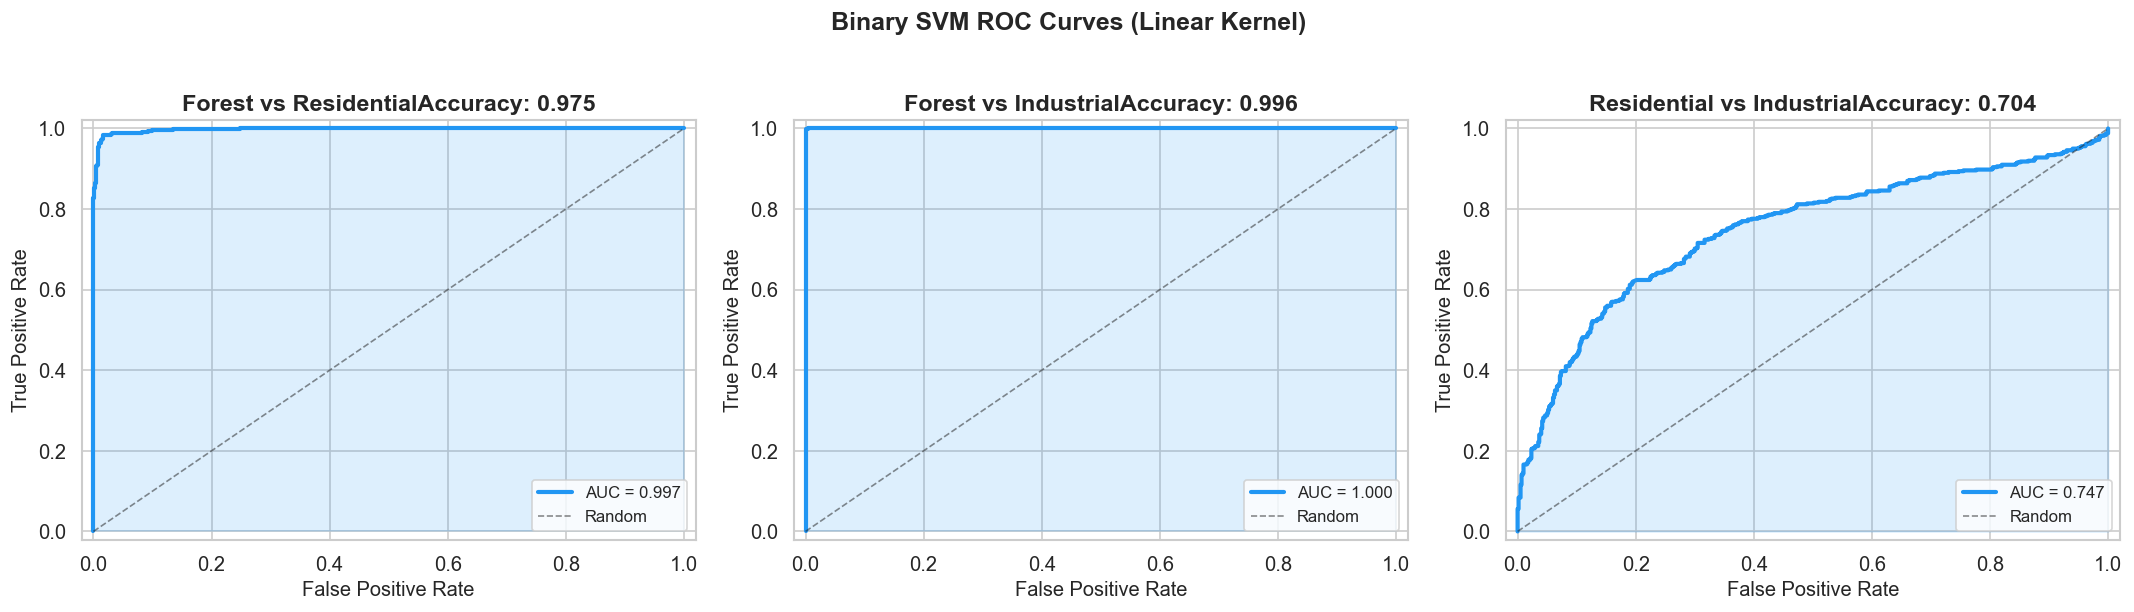

In [12]:
# =============================================================================
# 2.2b Visualize Binary SVM Results — ROC Curves
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pair_name, res) in zip(axes, svm_results.items()):
    ax.plot(res["fpr"], res["tpr"], color="#2196F3", lw=2.5,
            label=f'AUC = {res["auc"]:.3f}')
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
    ax.fill_between(res["fpr"], res["tpr"], alpha=0.15, color="#2196F3")
    ax.set_title(f"{pair_name}\
Accuracy: {res['acc']:.3f}", fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle("Binary SVM ROC Curves (Linear Kernel)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2.3 Multiclass SVM (Majority-Vote Ensemble)


In [13]:
# =============================================================================
# 2.3 Multiclass SVM — Majority vote of binary classifiers
# =============================================================================
# For each test sample, all 3 binary SVMs vote. The class with the most
# votes is the predicted class. Ties are broken by summing prediction
# probabilities across classifiers.

def majority_vote_predict(X, svm_models, binary_pairs, n_classes=3):
    """Predict multiclass labels using majority voting from binary SVMs."""
    n_samples = len(X)
    votes = np.zeros((n_samples, n_classes))  # vote counts
    confidence = np.zeros((n_samples, n_classes))  # cumulative confidence

    for (name_a, idx_a, name_b, idx_b) in binary_pairs:
        pair_name = f"{name_a} vs {name_b}"
        model = svm_models[pair_name]
        probs = model.predict_proba(X)

        # Class A gets probability of class 0, Class B gets probability of class 1
        preds = model.predict(X)
        for i in range(n_samples):
            if preds[i] == 0:  # voted for class A
                votes[i, idx_a] += 1
                confidence[i, idx_a] += probs[i, 0]
            else:  # voted for class B
                votes[i, idx_b] += 1
                confidence[i, idx_b] += probs[i, 1]

    # Break ties using cumulative confidence
    final_preds = []
    for i in range(n_samples):
        max_votes = votes[i].max()
        candidates = np.where(votes[i] == max_votes)[0]
        if len(candidates) == 1:
            final_preds.append(candidates[0])
        else:
            # Tie-break: choose the candidate with highest confidence
            best = candidates[np.argmax(confidence[i, candidates])]
            final_preds.append(best)

    return np.array(final_preds)


# Run majority-vote prediction on test set
y_ml_pred_svm = majority_vote_predict(X_ml_test, svm_models, binary_pairs)
svm_multi_acc = accuracy_score(y_ml_test, y_ml_pred_svm)

print(f"Multiclass SVM (Majority Vote) Accuracy: {svm_multi_acc:.4f}")
print(f"\
Classification Report:")
print(classification_report(y_ml_test, y_ml_pred_svm, target_names=ml_class_names))

Multiclass SVM (Majority Vote) Accuracy: 0.7976
Classification Report:
              precision    recall  f1-score   support

      Forest       0.96      0.99      0.97       600
  Industrial       0.70      0.65      0.67       500
 Residential       0.71      0.73      0.72       600

    accuracy                           0.80      1700
   macro avg       0.79      0.79      0.79      1700
weighted avg       0.79      0.80      0.80      1700



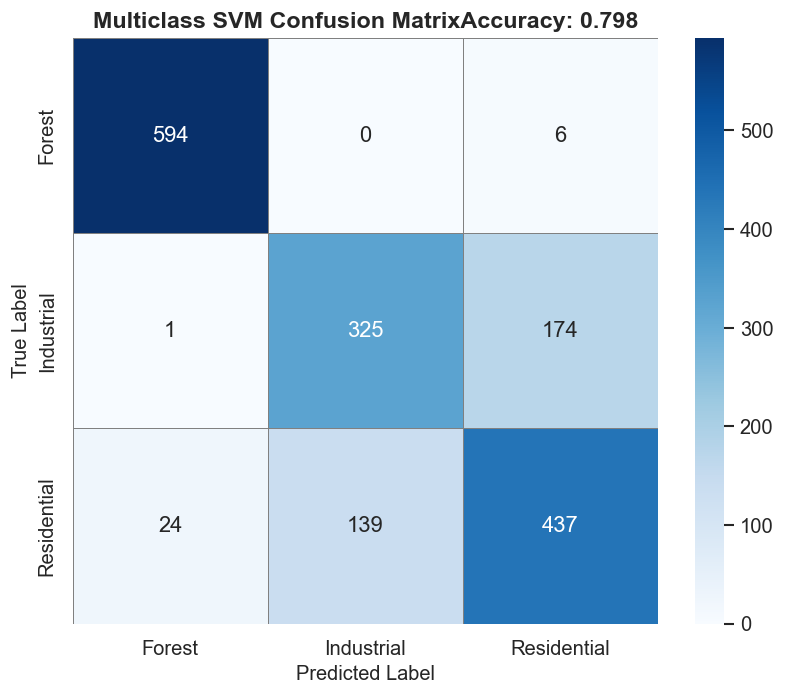

In [14]:
# =============================================================================
# 2.3b Confusion Matrix — Multiclass SVM
# =============================================================================

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_ml_test, y_ml_pred_svm)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=ml_class_names, yticklabels=ml_class_names,
    linewidths=0.5, linecolor="gray", ax=ax,
)
ax.set_title(f"Multiclass SVM Confusion Matrix\
Accuracy: {svm_multi_acc:.3f}", fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

## 2.4 Random Forest Classifier

Random Forest is an ensemble of decision trees that can directly handle multiclass classification. Unlike SVMs, it doesn't require one-vs-one decomposition. Each tree is trained on a bootstrapped sample, and the final prediction is the majority vote across all trees.

In [15]:
# =============================================================================
# 2.4 Random Forest Classifier
# =============================================================================
# We train a Random Forest with 200 trees on the 3-class grayscale data.

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,       # Let trees grow fully
    min_samples_split=5,
    random_state=SEED,
    n_jobs=-1,            # Use all CPU cores
)
rf.fit(X_ml_train, y_ml_train)

# Predictions
y_ml_pred_rf = rf.predict(X_ml_test)
y_ml_prob_rf = rf.predict_proba(X_ml_test)
rf_acc = accuracy_score(y_ml_test, y_ml_pred_rf)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"\
Classification Report:")
print(classification_report(y_ml_test, y_ml_pred_rf, target_names=ml_class_names))

Random Forest Accuracy: 0.9088
Classification Report:
              precision    recall  f1-score   support

      Forest       0.99      0.98      0.98       600
  Industrial       0.84      0.89      0.87       500
 Residential       0.89      0.85      0.87       600

    accuracy                           0.91      1700
   macro avg       0.91      0.91      0.91      1700
weighted avg       0.91      0.91      0.91      1700



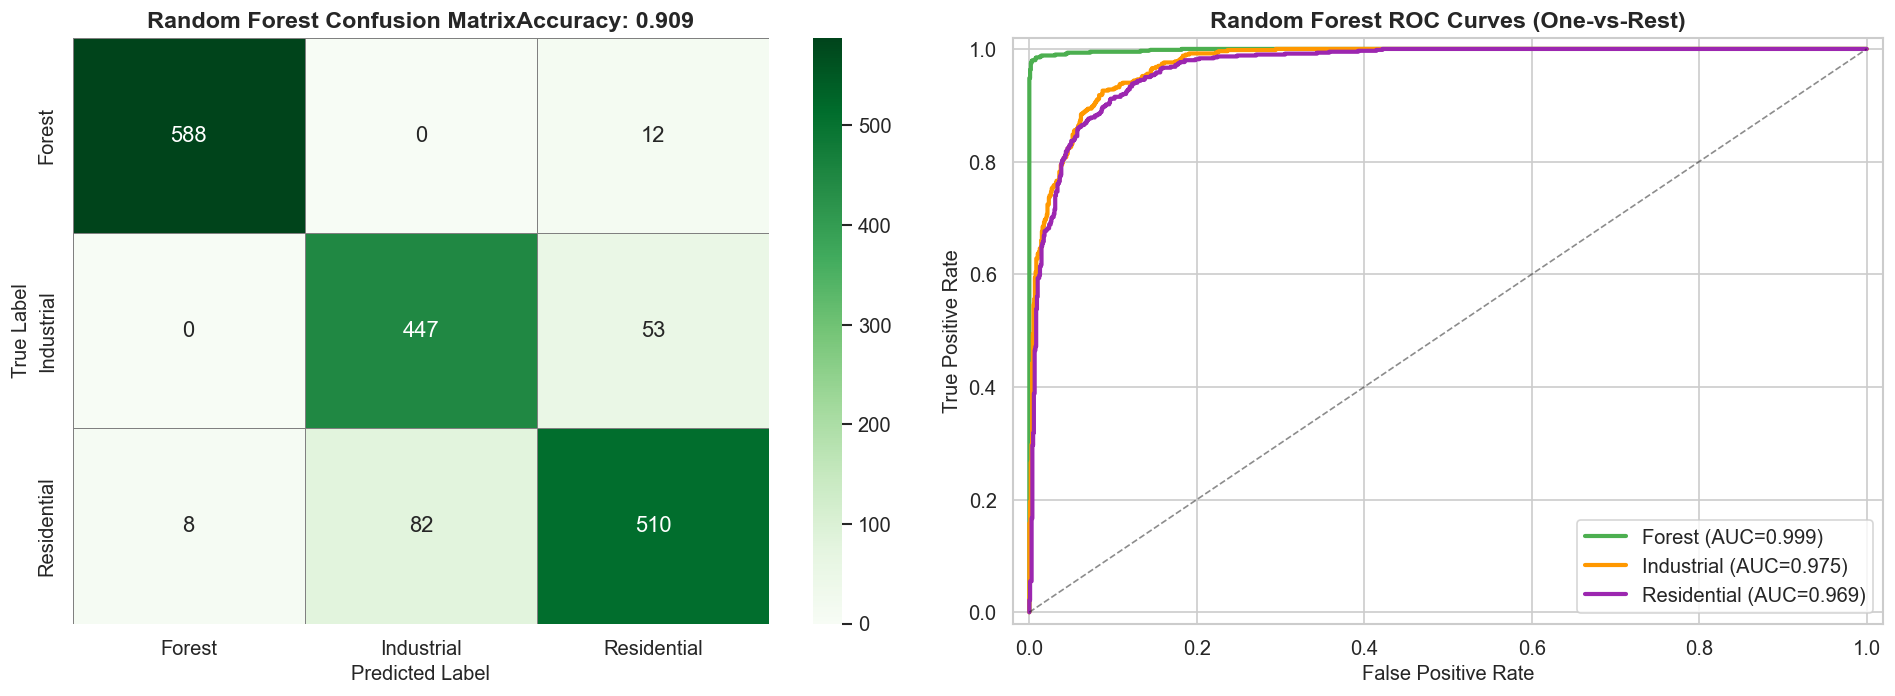

In [16]:
# =============================================================================
# 2.4b Confusion Matrix & ROC Curves — Random Forest
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_ml_test, y_ml_pred_rf)
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Greens",
    xticklabels=ml_class_names, yticklabels=ml_class_names,
    linewidths=0.5, linecolor="gray", ax=axes[0],
)
axes[0].set_title(f"Random Forest Confusion Matrix\
Accuracy: {rf_acc:.3f}", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# --- ROC Curves (one-vs-rest for each class) ---
y_ml_test_bin = label_binarize(y_ml_test, classes=[0, 1, 2])
rf_colors = ["#4CAF50", "#FF9800", "#9C27B0"]

for i, (name, color) in enumerate(zip(ml_class_names, rf_colors)):
    fpr_i, tpr_i, _ = roc_curve(y_ml_test_bin[:, i], y_ml_prob_rf[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[1].plot(fpr_i, tpr_i, color=color, lw=2.5,
                 label=f"{name} (AUC={auc_i:.3f})")

axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_title("Random Forest ROC Curves (One-vs-Rest)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

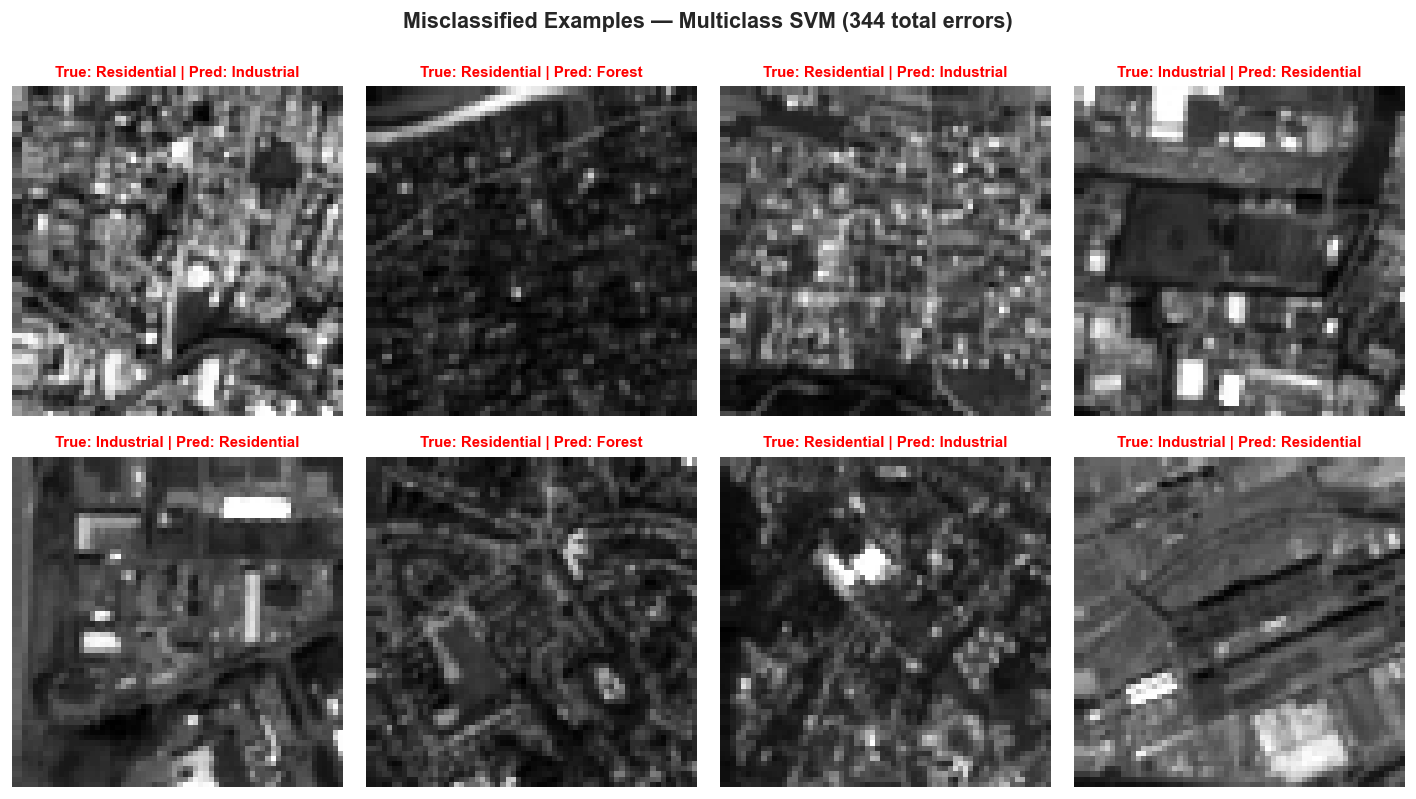

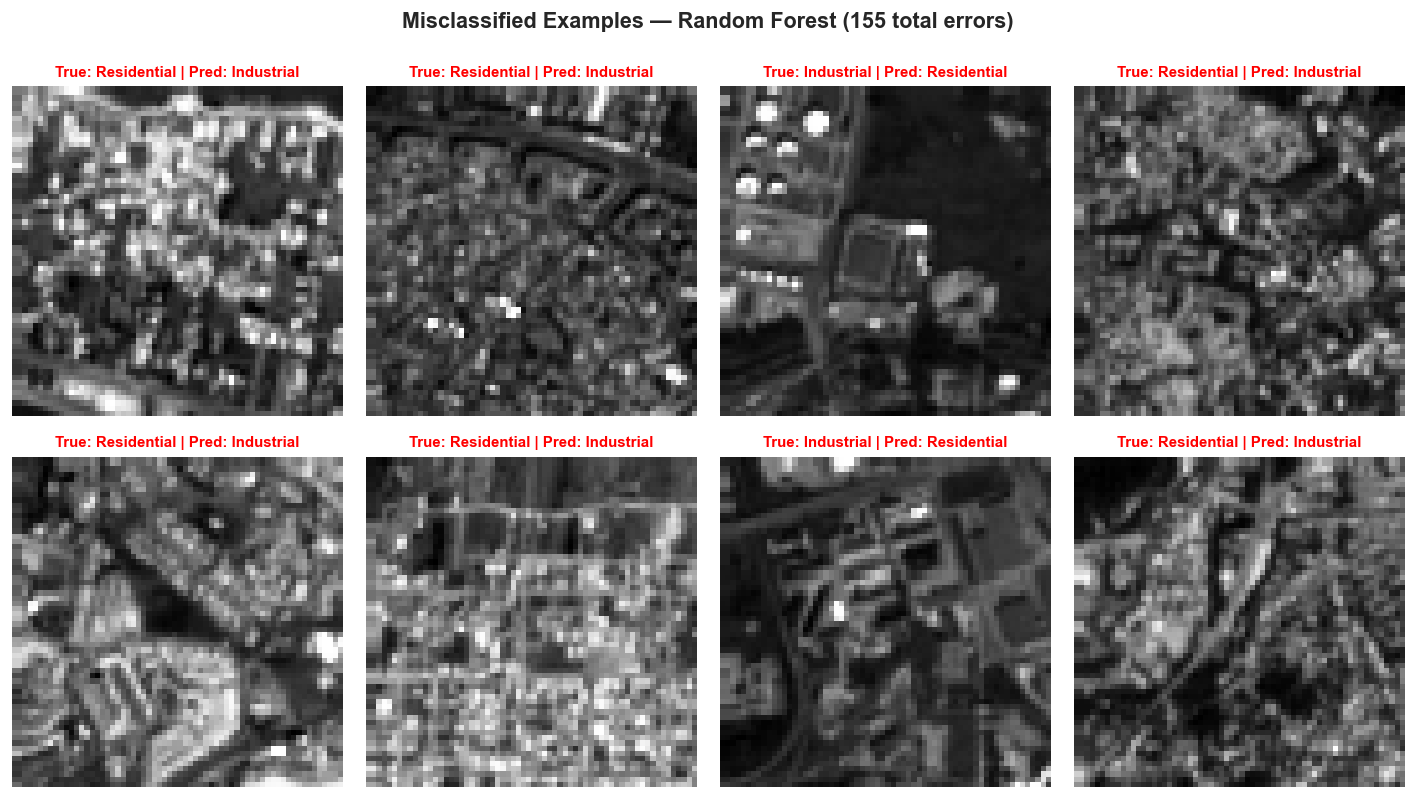

In [17]:
# =============================================================================
# 2.4c Visualize Misclassified Examples
# =============================================================================
# Show examples where the models made incorrect predictions.
# This helps us understand what types of images are most confusing.

def show_misclassified(y_true, y_pred, X_flat, model_name, class_names, n=8):
    """Display misclassified images in a grid."""
    wrong_idx = np.where(y_true != y_pred)[0]
    n_show = min(n, len(wrong_idx))

    if n_show == 0:
        print(f"{model_name}: No misclassified samples!")
        return

    fig, axes = plt.subplots(2, n_show // 2 if n_show > 1 else 1, figsize=(3 * (n_show // 2), 7))
    axes = np.array(axes).flatten()

    chosen = np.random.choice(wrong_idx, n_show, replace=False)
    for i, idx in enumerate(chosen):
        # Reshape flattened grayscale back to 64x64
        img = X_flat[idx].reshape(64, 64)
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(
            f"True: {class_names[y_true[idx]]} | Pred: {class_names[y_pred[idx]]}",
            fontsize=9, color="red", fontweight="bold",
        )
        axes[i].axis("off")

    plt.suptitle(f"Misclassified Examples — {model_name} ({len(wrong_idx)} total errors)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_misclassified(y_ml_test, y_ml_pred_svm, X_ml_test, "Multiclass SVM", ml_class_names)
show_misclassified(y_ml_test, y_ml_pred_rf, X_ml_test, "Random Forest", ml_class_names)

## 2.5 Traditional ML Summary

| Model | Accuracy | Notes |
|-------|----------|-------|
| Binary SVM (F vs R) | 0.9750 | Linear kernel, one-vs-one |
| Binary SVM (F vs I) | 0.9964 | Linear kernel, one-vs-one |
| Binary SVM (R vs I) | 0.7036 | Linear kernel, one-vs-one |
| Multiclass SVM (Majority Vote) | 0.7976 | Ensemble of 3 binary SVMs |
| Random Forest | 0.9088 | 200 trees, direct multiclass |

> Accuracy values are printed above. The key takeaway is that even simple ML models on flattened grayscale pixels can achieve reasonable accuracy for visually distinct land cover classes like Forest, Industrial, and Residential.

---

# 3. Deep Learning

In this section, we apply deep learning models to classify **all 10 land cover classes** in EuroSAT. We progressively increase model complexity:

### Grayscale Models (flattened 4,096-dim input)
1. **Single fully-connected layer** — baseline linear classifier
2. **Two-layer network** — adds a hidden layer with nonlinearity
3. **Four-layer network with dropout** — deeper architecture with regularization
4. **Ensemble** — combines predictions from all three grayscale models

### RGB Models (64×64×3 image input)
5. **CNN** — Convolutional neural network with Conv2D, MaxPool, Dropout
6. **Transfer Learning** — Fine-tuned pre-trained ResNet18

### Multispectral
7. **Best model on multispectral channels**

## 3.0 Helper Functions

In [18]:
# =============================================================================
# 3.0 Training & Evaluation Helper Functions
# =============================================================================
# Reusable functions for training, evaluation, and visualization of DL models.

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, model_name="Model"):
    """Train a PyTorch model, select the best epoch on validation accuracy, and return history."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -np.inf
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_loss += loss.item() * len(y_batch)
                preds = outputs.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += len(y_batch)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
            )

    model.load_state_dict(best_state)
    print(f"Best {model_name} validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
    return history


def plot_training_history(history, model_name="Model"):
    """Plot training/validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="Train", lw=2)
    axes[0].plot(history["val_loss"], label="Validation", lw=2, linestyle="--")
    axes[0].set_title(f"{model_name} — Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train", lw=2)
    axes[1].plot(history["val_acc"], label="Validation", lw=2, linestyle="--")
    axes[1].set_title(f"{model_name} — Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


def evaluate_model(model, data_loader, class_names, split_name="Test"):
    """Get predictions for a held-out split and print a classification report."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{split_name} Accuracy: {acc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return all_preds, all_labels, acc


def plot_confusion_matrix_dl(y_true, y_pred, class_names, model_name, acc):
    """Plot a confusion matrix heatmap for a DL model."""
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.3,
        ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix\nAccuracy: {acc:.3f}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")


Helper functions defined.


## 3.1 Grayscale Model 1: Single Fully-Connected Layer



FC1 Parameters: 40,970
FC1(
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)

Training FC1 (Single Layer)...
  Epoch   1/30 | Train Loss: 2.3157 Acc: 0.1365 | Val Loss: 2.2775 Acc: 0.1506
  Epoch   5/30 | Train Loss: 2.1731 Acc: 0.2081 | Val Loss: 2.2535 Acc: 0.1639
  Epoch  10/30 | Train Loss: 2.1263 Acc: 0.2422 | Val Loss: 2.3287 Acc: 0.1404
  Epoch  15/30 | Train Loss: 2.0355 Acc: 0.2761 | Val Loss: 2.0522 Acc: 0.2956
  Epoch  20/30 | Train Loss: 1.9949 Acc: 0.2901 | Val Loss: 2.1090 Acc: 0.2204
  Epoch  25/30 | Train Loss: 1.9489 Acc: 0.3033 | Val Loss: 2.0959 Acc: 0.2311
  Epoch  30/30 | Train Loss: 1.9397 Acc: 0.3032 | Val Loss: 2.0822 Acc: 0.2567
Best FC1 validation accuracy: 0.2956 (epoch 15)


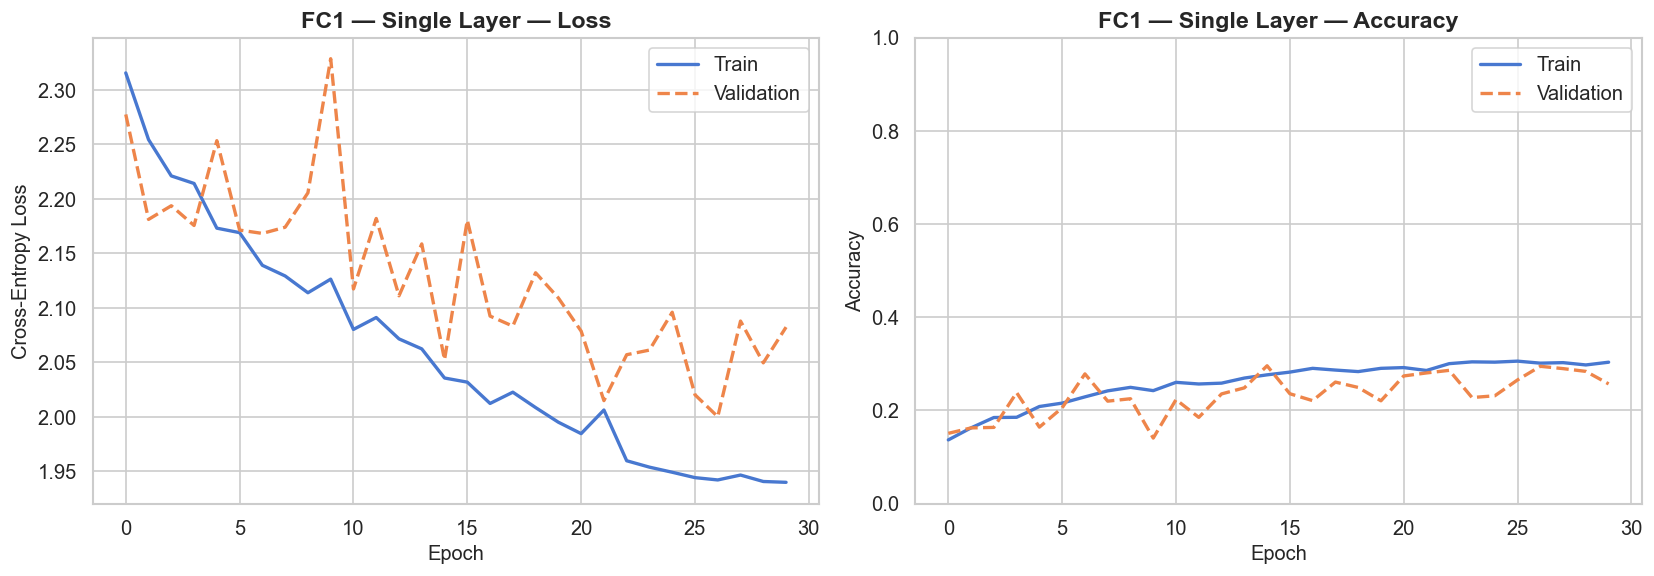


Test Accuracy: 0.2776
                      precision    recall  f1-score   support

          AnnualCrop       0.19      0.59      0.28       600
              Forest       0.56      0.81      0.66       600
HerbaceousVegetation       0.00      0.00      0.00       600
             Highway       0.13      0.28      0.18       500
          Industrial       0.48      0.52      0.50       500
             Pasture       0.00      0.00      0.00       400
       PermanentCrop       0.10      0.02      0.03       500
         Residential       0.17      0.12      0.14       600
               River       0.35      0.31      0.33       500
             SeaLake       0.32      0.03      0.06       600

            accuracy                           0.28      5400
           macro avg       0.23      0.27      0.22      5400
        weighted avg       0.24      0.28      0.22      5400



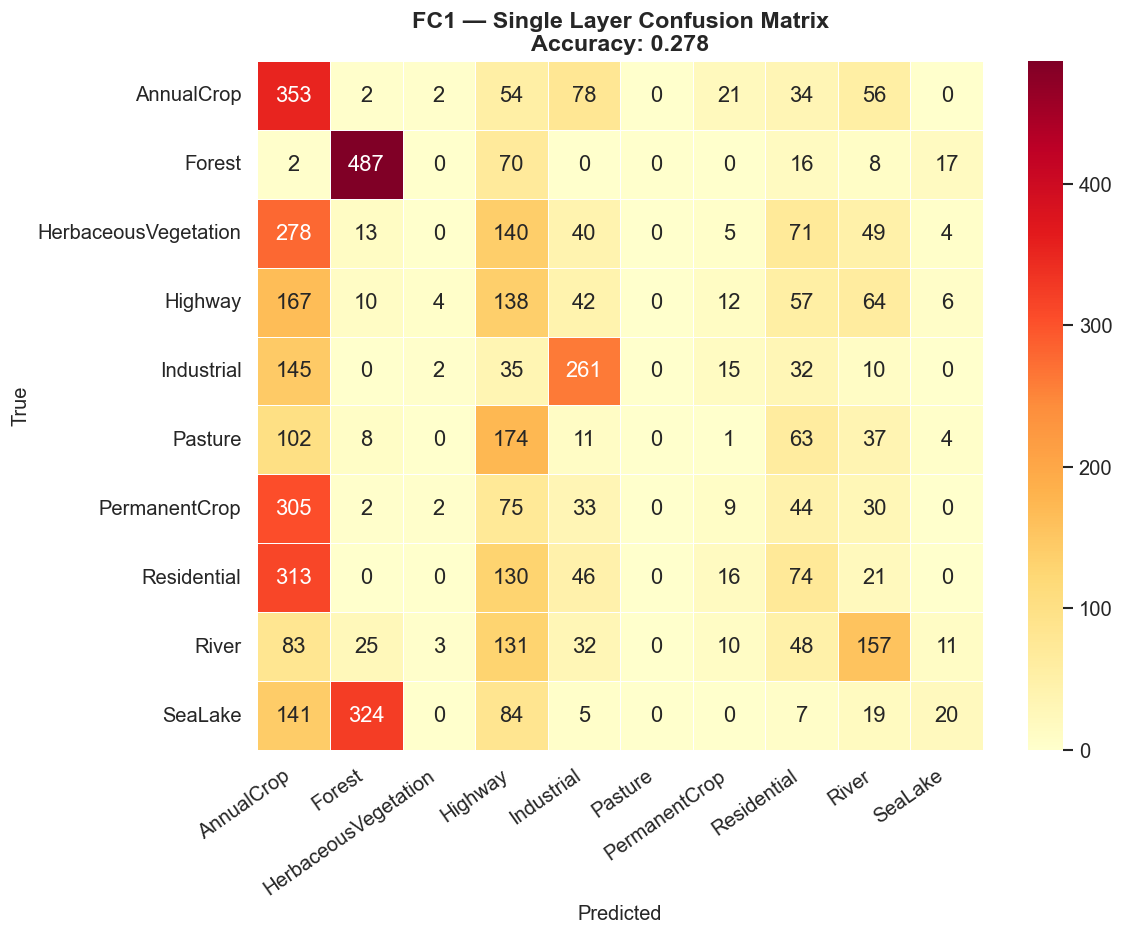

In [19]:
# =============================================================================
# 3.1 Single Fully-Connected Layer (Grayscale)
# =============================================================================
# Architecture: Input(4096) -> Linear(10) -> Softmax
# This is a linear classifier — no hidden layers, no nonlinearity.

class FC1(nn.Module):
    def __init__(self, input_dim=4096, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


fc1_model = FC1()
print(f"FC1 Parameters: {sum(p.numel() for p in fc1_model.parameters()):,}")
print(fc1_model)

print("\nTraining FC1 (Single Layer)...")
fc1_history = train_model(
    fc1_model,
    train_gray_loader,
    val_gray_loader,
    epochs=30,
    lr=1e-3,
    model_name="FC1",
)
plot_training_history(fc1_history, "FC1 — Single Layer")

fc1_preds, fc1_labels, fc1_acc = evaluate_model(fc1_model, test_gray_loader, class_names, split_name="Test")
plot_confusion_matrix_dl(fc1_labels, fc1_preds, class_names, "FC1 — Single Layer", fc1_acc)


## 3.2 Grayscale Model 2: Two-Layer Network

Adding a **hidden layer with ReLU activation** allows the model to learn nonlinear decision boundaries. The hidden layer acts as a learned feature extractor that transforms the raw pixel space into a more separable representation.

FC2 Parameters: 2,102,794
FC2(
  (net): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
)

Training FC2 (Two Layers)...
  Epoch   1/30 | Train Loss: 2.2616 Acc: 0.1312 | Val Loss: 2.1954 Acc: 0.1478
  Epoch   5/30 | Train Loss: 2.0285 Acc: 0.2673 | Val Loss: 2.0087 Acc: 0.2837
  Epoch  10/30 | Train Loss: 1.8100 Acc: 0.3194 | Val Loss: 1.8008 Acc: 0.3148
  Epoch  15/30 | Train Loss: 1.7151 Acc: 0.3456 | Val Loss: 1.7777 Acc: 0.3263
  Epoch  20/30 | Train Loss: 1.6719 Acc: 0.3535 | Val Loss: 1.7716 Acc: 0.3280
  Epoch  25/30 | Train Loss: 1.6410 Acc: 0.3675 | Val Loss: 1.6810 Acc: 0.3441
  Epoch  30/30 | Train Loss: 1.6278 Acc: 0.3703 | Val Loss: 1.6762 Acc: 0.3528
Best FC2 validation accuracy: 0.3633 (epoch 28)


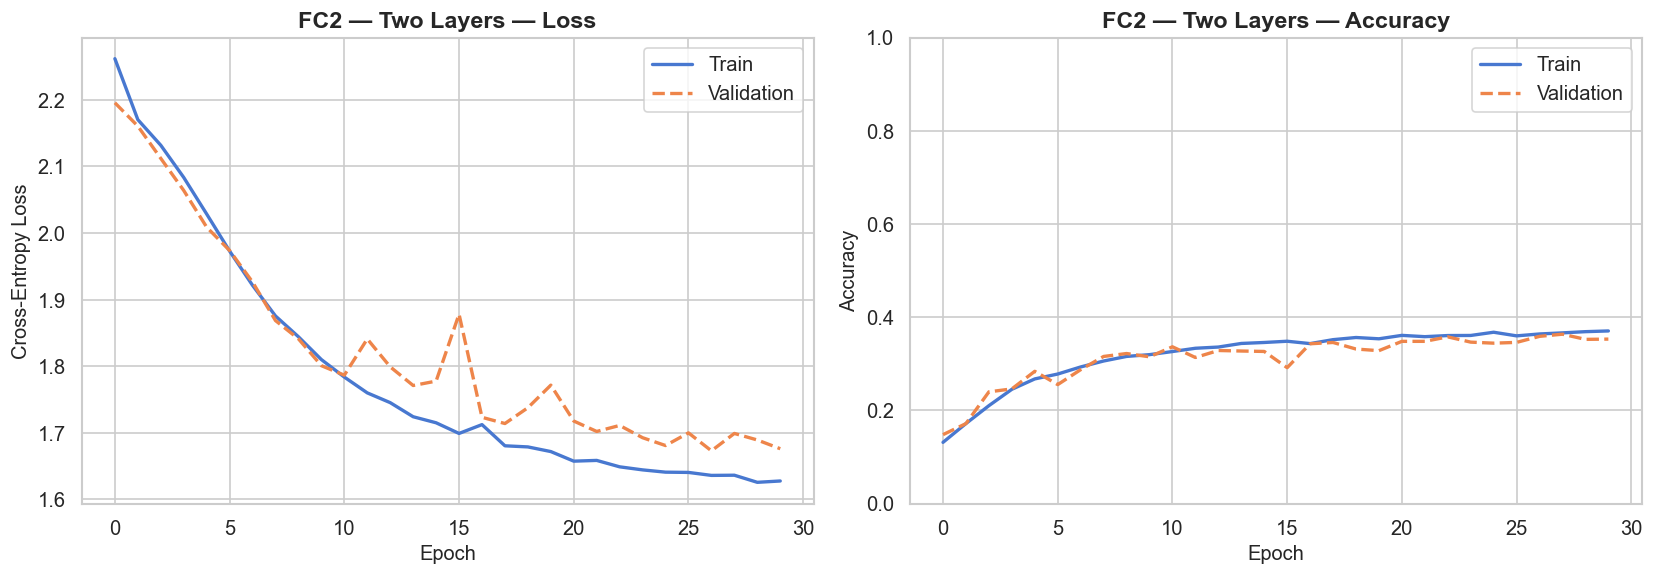


Test Accuracy: 0.3552
                      precision    recall  f1-score   support

          AnnualCrop       0.34      0.39      0.36       600
              Forest       0.59      0.81      0.68       600
HerbaceousVegetation       0.21      0.10      0.14       600
             Highway       0.32      0.14      0.19       500
          Industrial       0.42      0.68      0.52       500
             Pasture       0.33      0.11      0.16       400
       PermanentCrop       0.25      0.18      0.21       500
         Residential       0.28      0.46      0.35       600
               River       0.35      0.44      0.39       500
             SeaLake       0.19      0.15      0.17       600

            accuracy                           0.36      5400
           macro avg       0.33      0.35      0.32      5400
        weighted avg       0.33      0.36      0.32      5400



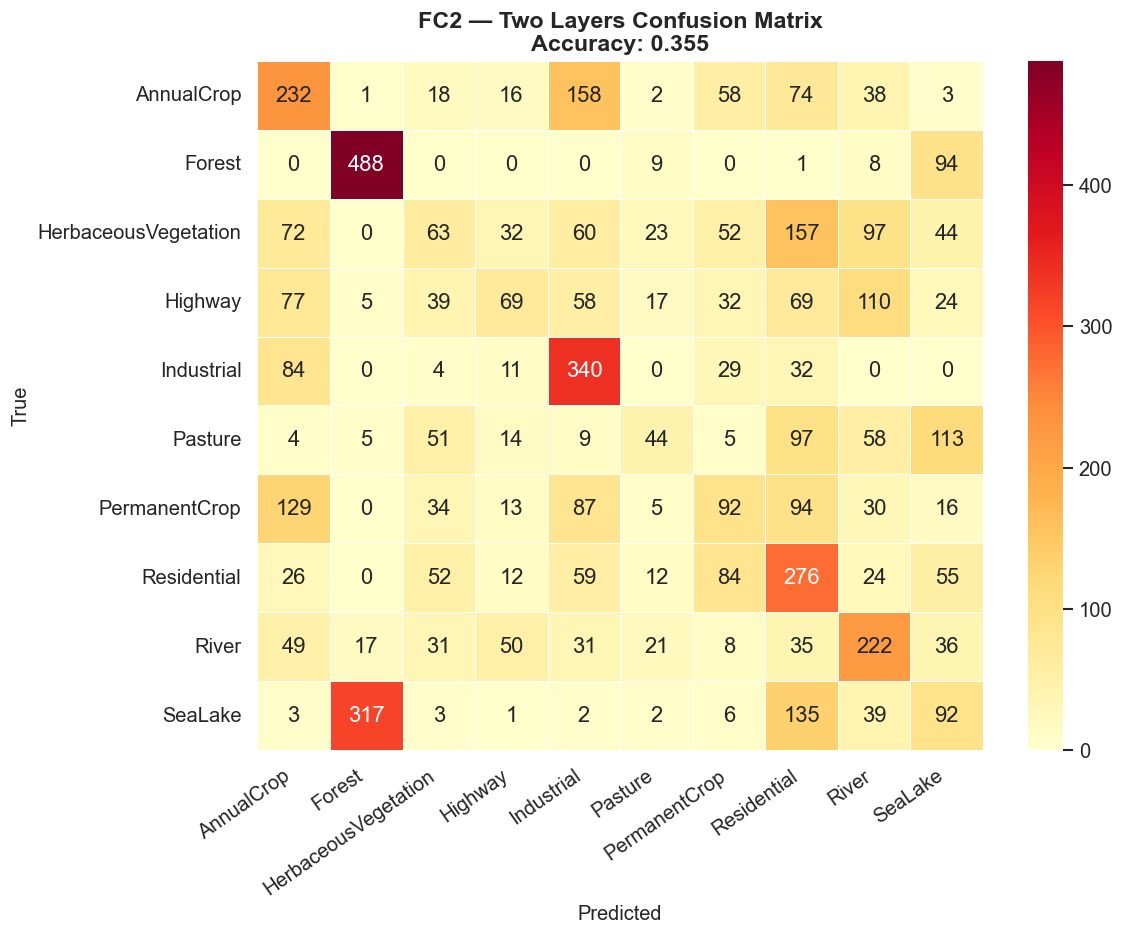

In [20]:
# =============================================================================
# 3.2 Two-Layer Network (Grayscale)
# =============================================================================
# Architecture: Input(4096) -> Linear(512) -> ReLU -> Linear(10)
# The hidden layer with 512 units learns intermediate representations.

class FC2(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


fc2_model = FC2()
print(f"FC2 Parameters: {sum(p.numel() for p in fc2_model.parameters()):,}")
print(fc2_model)

print("\nTraining FC2 (Two Layers)...")
fc2_history = train_model(
    fc2_model,
    train_gray_loader,
    val_gray_loader,
    epochs=30,
    lr=1e-3,
    model_name="FC2",
)
plot_training_history(fc2_history, "FC2 — Two Layers")

fc2_preds, fc2_labels, fc2_acc = evaluate_model(fc2_model, test_gray_loader, class_names, split_name="Test")
plot_confusion_matrix_dl(fc2_labels, fc2_preds, class_names, "FC2 — Two Layers", fc2_acc)


## 3.3 Grayscale Model 3: Four-Layer Network with Dropout

A deeper network with **dropout regularization** to prevent overfitting. Dropout randomly zeroes out a fraction of neurons during training, forcing the network to learn more robust features that don't depend on any single neuron.

FC4 Parameters: 4,857,610
FC4(
  (net): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)

Training FC4 (Four Layers + Dropout)...
  Epoch   1/40 | Train Loss: 1.7446 Acc: 0.3335 | Val Loss: 2.0917 Acc: 0.3217
  Epoch   5/40 | Train Loss: 1.4920 Acc: 0.4310 | Val Loss: 1.6783 Acc: 0.3881
  Epoch  10/40 | Train Loss: 1.3992 Acc: 0.4692 | Val 

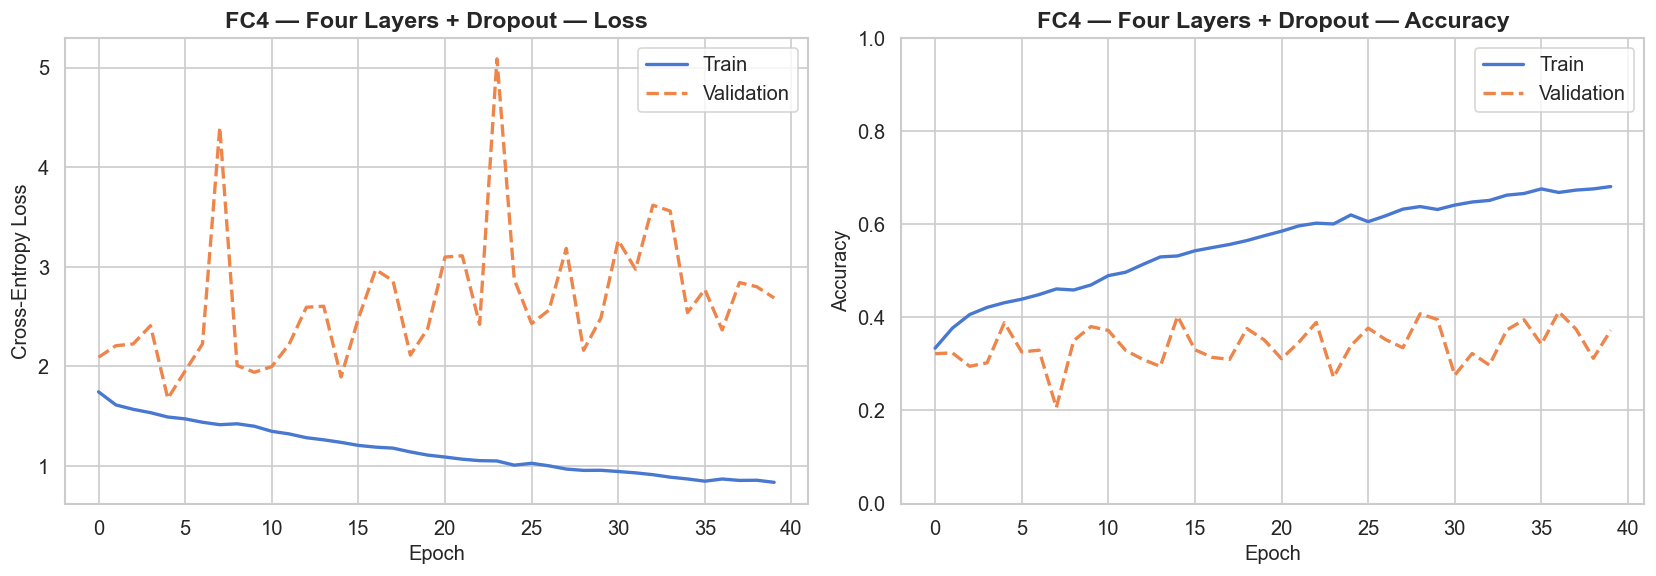


Test Accuracy: 0.3989
                      precision    recall  f1-score   support

          AnnualCrop       0.52      0.27      0.35       600
              Forest       0.70      0.79      0.74       600
HerbaceousVegetation       0.26      0.05      0.08       600
             Highway       0.37      0.28      0.32       500
          Industrial       0.52      0.74      0.61       500
             Pasture       0.30      0.03      0.05       400
       PermanentCrop       0.27      0.33      0.30       500
         Residential       0.30      0.47      0.36       600
               River       0.25      0.67      0.36       500
             SeaLake       0.73      0.31      0.43       600

            accuracy                           0.40      5400
           macro avg       0.42      0.39      0.36      5400
        weighted avg       0.43      0.40      0.37      5400



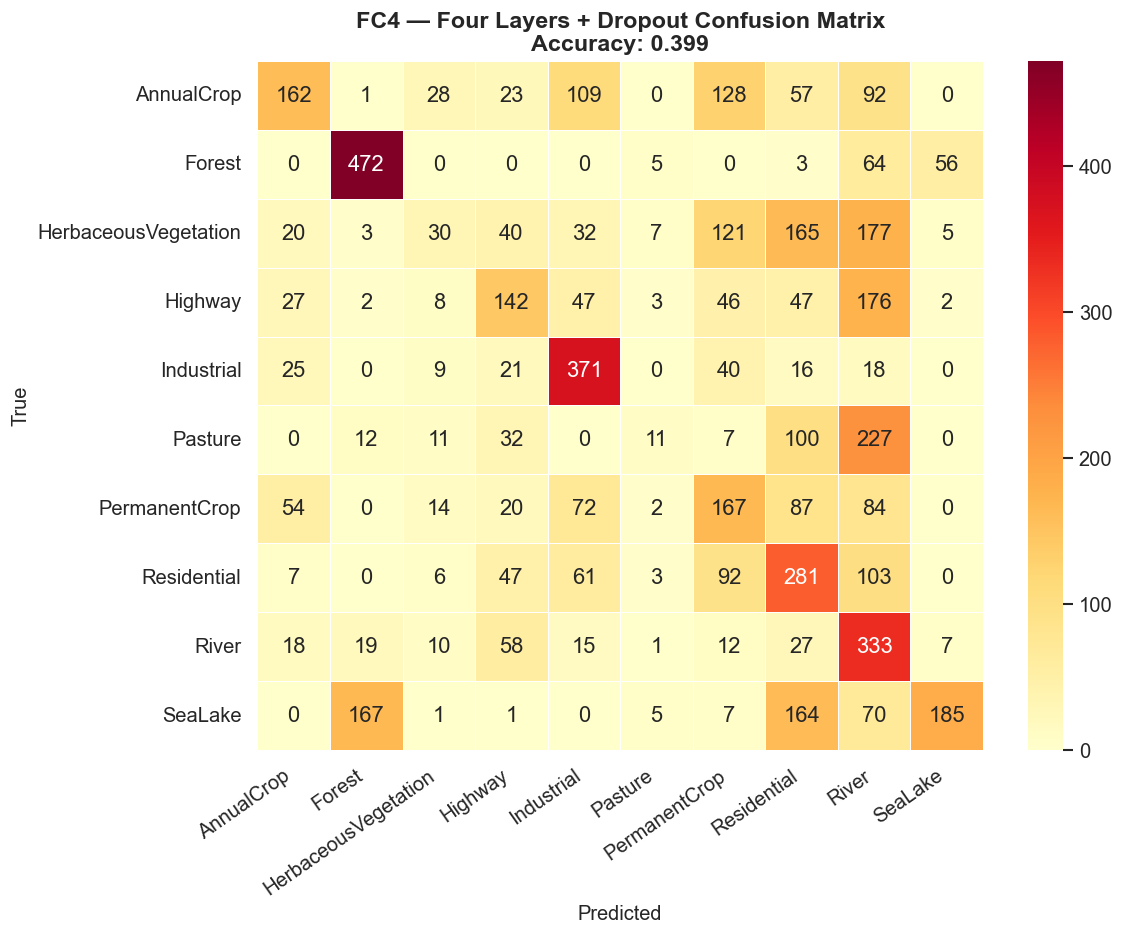

In [21]:
# =============================================================================
# 3.3 Four-Layer Network with Dropout (Grayscale)
# =============================================================================
# Architecture: Input(4096) -> 1024 -> 512 -> 256 -> 10
# Each hidden layer: Linear -> BatchNorm -> ReLU -> Dropout(0.3)
# Dropout rate of 0.3 provides moderate regularization.

class FC4(nn.Module):
    def __init__(self, input_dim=4096, num_classes=10, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


fc4_model = FC4()
print(f"FC4 Parameters: {sum(p.numel() for p in fc4_model.parameters()):,}")
print(fc4_model)

print("\nTraining FC4 (Four Layers + Dropout)...")
fc4_history = train_model(
    fc4_model,
    train_gray_loader,
    val_gray_loader,
    epochs=40,
    lr=1e-3,
    model_name="FC4",
)
plot_training_history(fc4_history, "FC4 — Four Layers + Dropout")

fc4_preds, fc4_labels, fc4_acc = evaluate_model(fc4_model, test_gray_loader, class_names, split_name="Test")
plot_confusion_matrix_dl(fc4_labels, fc4_preds, class_names, "FC4 — Four Layers + Dropout", fc4_acc)


## 3.4 Grayscale Ensemble

We combine the three grayscale models (FC1, FC2, FC4) by **averaging their softmax probabilities**. Ensembling leverages the diversity of different architectures. Each model may capture different aspects of the data, and their combined prediction is often more robust than any individual model.

Grayscale Ensemble Accuracy: 0.4030
Individual model accuracies for comparison:
  FC1 (1 layer)          : 0.2776
  FC2 (2 layers)         : 0.3552
  FC4 (4 layers+dropout) : 0.3989
  Ensemble (average)     : 0.4030
Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.44      0.35      0.39       600
              Forest       0.65      0.85      0.74       600
HerbaceousVegetation       0.29      0.04      0.07       600
             Highway       0.38      0.29      0.33       500
          Industrial       0.52      0.75      0.61       500
             Pasture       0.26      0.03      0.05       400
       PermanentCrop       0.29      0.32      0.31       500
         Residential       0.30      0.48      0.37       600
               River       0.26      0.64      0.37       500
             SeaLake       0.81      0.22      0.34       600

            accuracy                           0.40      5400
           macr

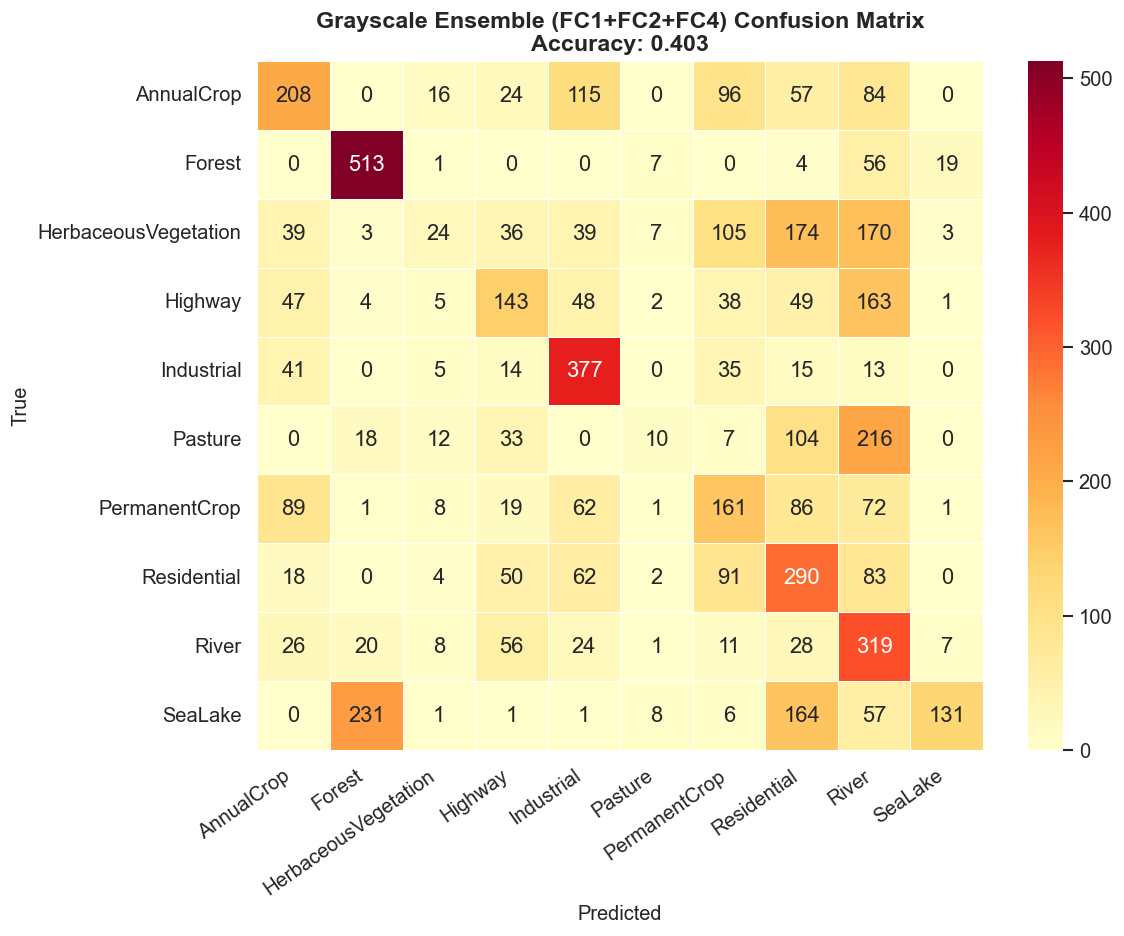

In [22]:
# =============================================================================
# 3.4 Grayscale Ensemble — Average of FC1 + FC2 + FC4
# =============================================================================
# Ensemble strategy: average the softmax output probabilities from all three
# models, then take the argmax as the final prediction.

def ensemble_predict(models, test_loader):
    """Average softmax probabilities from multiple models."""
    all_probs = []
    all_labels = []

    for model in models:
        model.eval()
        model_probs = []
        labels = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                probs = torch.softmax(outputs, dim=1)
                model_probs.append(probs.cpu().numpy())
                labels.append(y_batch.numpy())
        all_probs.append(np.concatenate(model_probs, axis=0))
        all_labels = np.concatenate(labels, axis=0)

    # Average probabilities across models
    avg_probs = np.mean(all_probs, axis=0)
    ensemble_preds = np.argmax(avg_probs, axis=1)
    return ensemble_preds, all_labels


# Run ensemble prediction
ensemble_preds, ensemble_labels = ensemble_predict(
    [fc1_model, fc2_model, fc4_model], test_gray_loader
)
ensemble_acc = accuracy_score(ensemble_labels, ensemble_preds)

print(f"Grayscale Ensemble Accuracy: {ensemble_acc:.4f}")
print(f"\
Individual model accuracies for comparison:")
print(f"  FC1 (1 layer)          : {fc1_acc:.4f}")
print(f"  FC2 (2 layers)         : {fc2_acc:.4f}")
print(f"  FC4 (4 layers+dropout) : {fc4_acc:.4f}")
print(f"  Ensemble (average)     : {ensemble_acc:.4f}")

print(f"\
Classification Report:")
print(classification_report(ensemble_labels, ensemble_preds, target_names=class_names))
plot_confusion_matrix_dl(ensemble_labels, ensemble_preds, class_names,
                         "Grayscale Ensemble (FC1+FC2+FC4)", ensemble_acc)

## 3.5 RGB CNN

Convolutional Neural Networks (CNNs) are specifically designed for image data. Unlike fully-connected networks that treat each pixel independently, CNNs use **local filters** that slide across the image to detect spatial patterns (edges, textures, shapes). This makes them fundamentally better suited for image classification.

Architecture:
- 3 convolutional blocks: Conv2D -> BatchNorm -> ReLU -> MaxPool -> Dropout
- Flatten -> FC layers -> Output

CNN Parameters: 2,193,674
EuroSATCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.25, inplace=False)
  )
  (class

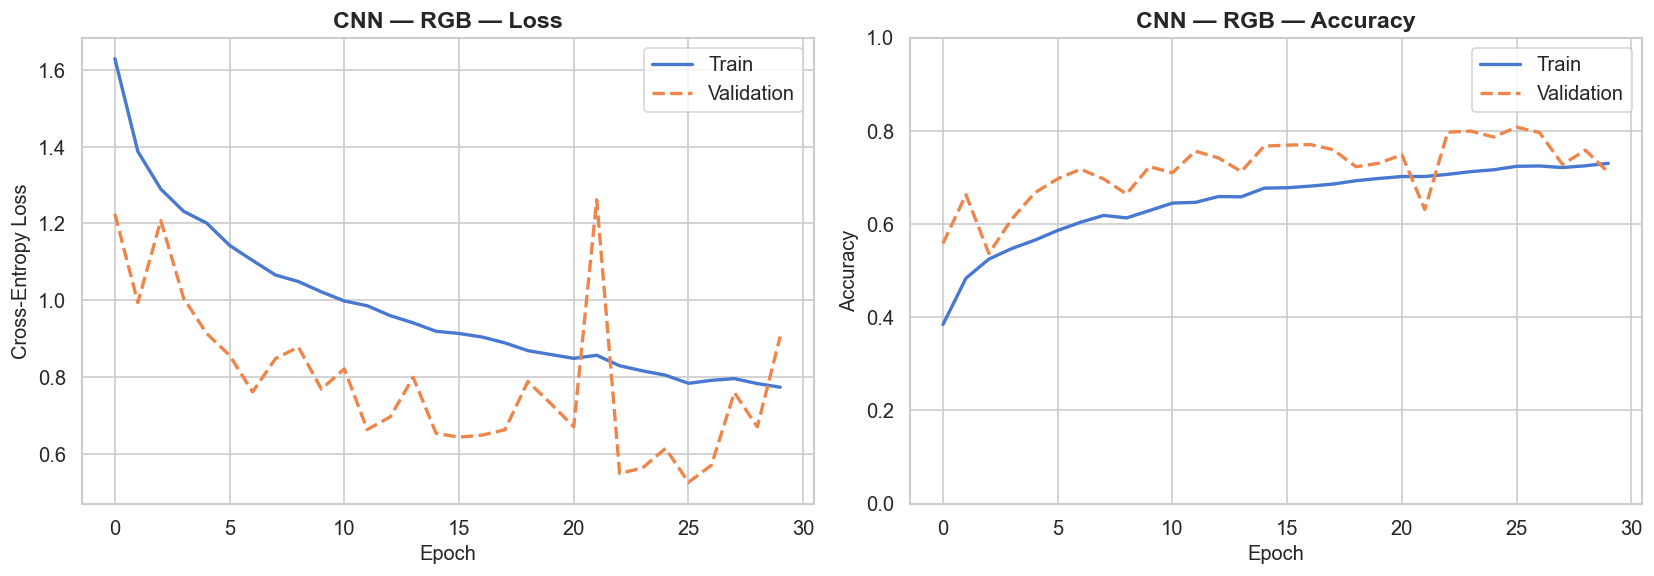


Test Accuracy: 0.8165
                      precision    recall  f1-score   support

          AnnualCrop       0.73      0.86      0.79       600
              Forest       0.94      0.96      0.95       600
HerbaceousVegetation       0.79      0.64      0.71       600
             Highway       0.72      0.53      0.61       500
          Industrial       0.93      0.92      0.92       500
             Pasture       0.80      0.86      0.83       400
       PermanentCrop       0.59      0.66      0.62       500
         Residential       0.91      0.97      0.94       600
               River       0.75      0.75      0.75       500
             SeaLake       0.95      0.97      0.96       600

            accuracy                           0.82      5400
           macro avg       0.81      0.81      0.81      5400
        weighted avg       0.82      0.82      0.81      5400



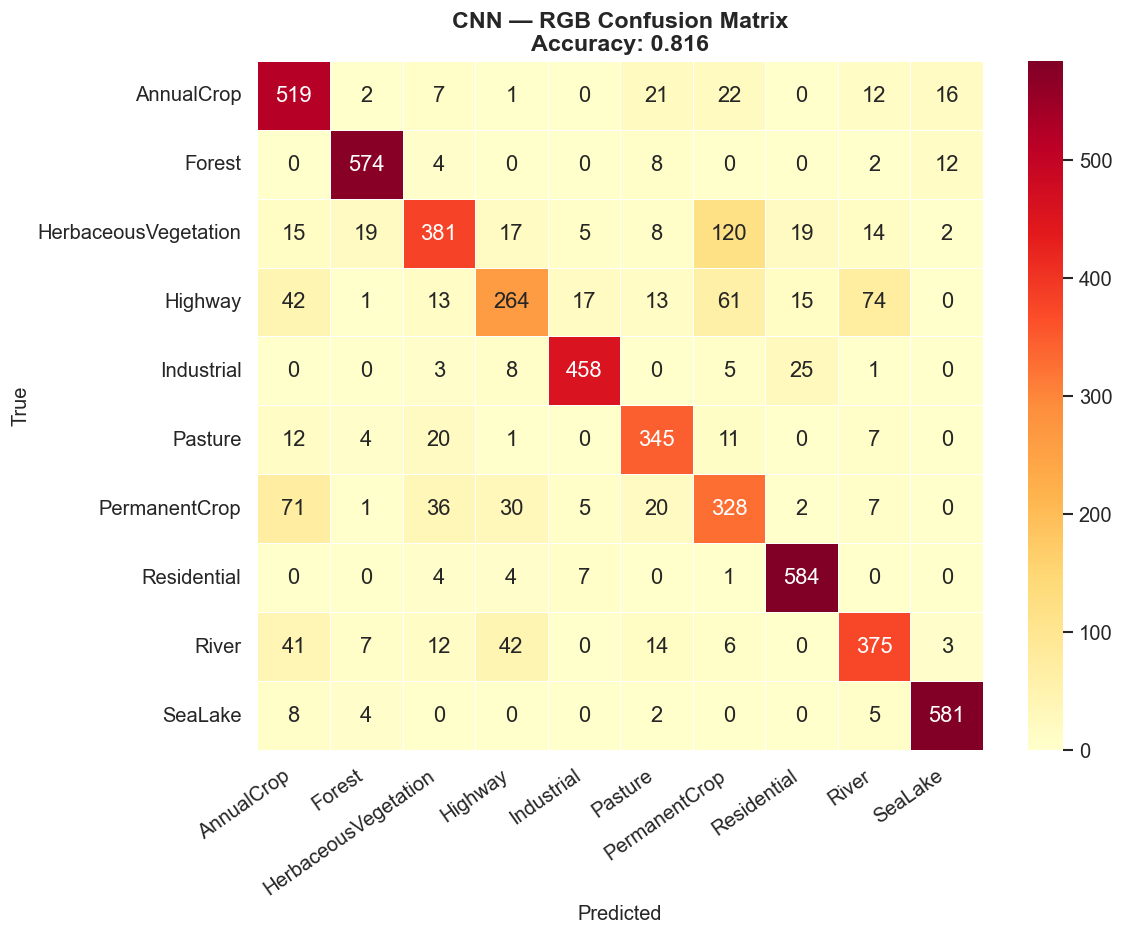

In [23]:
# =============================================================================
# 3.5 CNN for RGB Images
# =============================================================================
# A custom CNN with 3 convolutional blocks followed by fully-connected layers.
# Input: (batch, 3, 64, 64) RGB images
#
# Conv Block: Conv2D(3x3) -> BatchNorm -> ReLU -> MaxPool(2x2) -> Dropout
# Feature map sizes: 3 -> 32 -> 64 -> 128
# Spatial dimensions: 64 -> 32 -> 16 -> 8
# After flatten: 128 * 8 * 8 = 8192

class EuroSATCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = EuroSATCNN()
print(f"CNN Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(cnn_model)

print("\nTraining CNN (RGB)...")
cnn_history = train_model(
    cnn_model,
    train_rgb_loader,
    val_rgb_loader,
    epochs=30,
    lr=1e-3,
    model_name="CNN",
)
plot_training_history(cnn_history, "CNN — RGB")

cnn_preds, cnn_labels, cnn_acc = evaluate_model(cnn_model, test_rgb_loader, class_names, split_name="Test")
plot_confusion_matrix_dl(cnn_labels, cnn_preds, class_names, "CNN — RGB", cnn_acc)


## 3.6 Transfer Learning — Fine-tuned ResNet18

**Transfer learning** leverages a model pre-trained on ImageNet (1.2M natural images) and fine-tunes it on our satellite imagery. 

We use **ResNet18** — a relatively lightweight architecture with residual connections. We:
1. Load pre-trained weights
2. Replace the final FC layer to output 10 classes
3. Fine-tune all layers with a lower learning rate

Preparing ResNet datasets with on-the-fly transforms...
ResNet train samples : 16200
ResNet val samples   : 5400
ResNet sample shape  : torch.Size([3, 224, 224])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/lc/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.33MB/s]



ResNet18 Parameters: 11,181,642
Trainable params  : 11,181,642

Training ResNet18 (Transfer Learning)...
  Epoch   1/15 | Train Loss: 0.2638 Acc: 0.9155 | Val Loss: 0.1180 Acc: 0.9607
  Epoch   5/15 | Train Loss: 0.0733 Acc: 0.9755 | Val Loss: 0.0685 Acc: 0.9770
  Epoch  10/15 | Train Loss: 0.0593 Acc: 0.9810 | Val Loss: 0.0568 Acc: 0.9811
  Epoch  15/15 | Train Loss: 0.0389 Acc: 0.9865 | Val Loss: 0.0624 Acc: 0.9819
Best ResNet18 validation accuracy: 0.9826 (epoch 11)


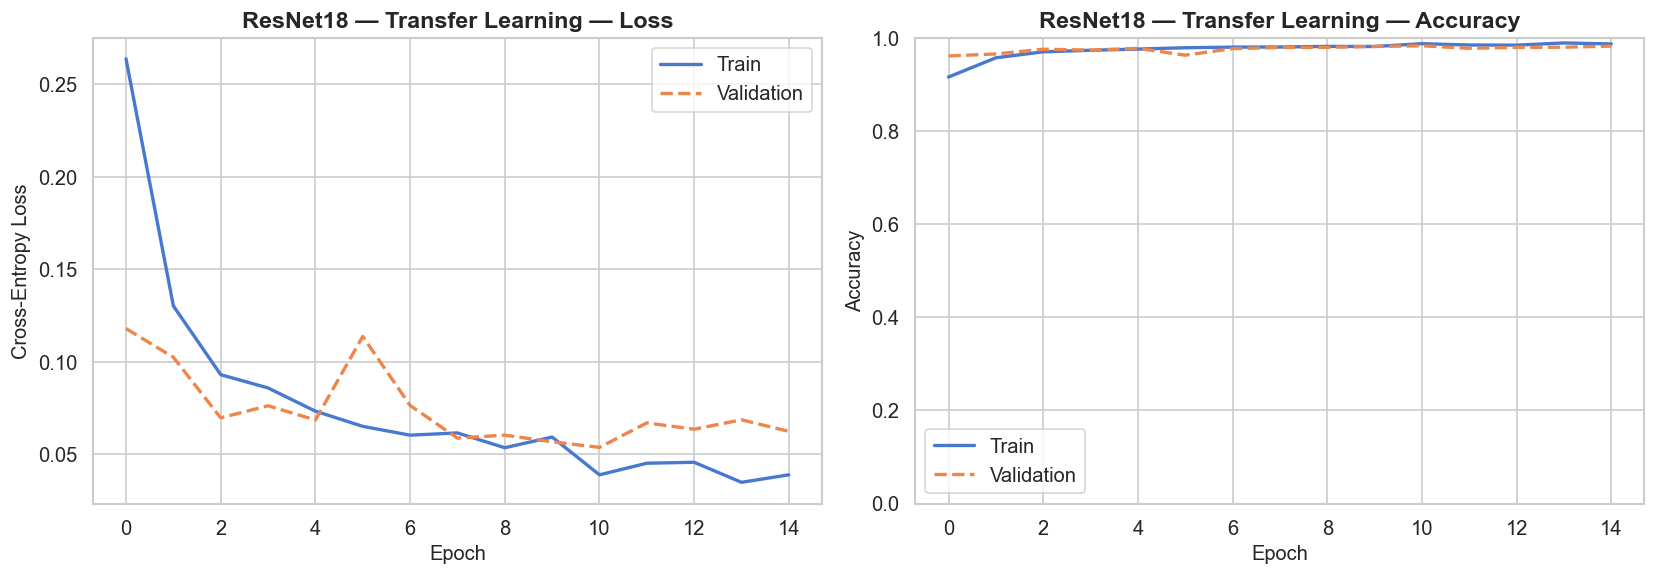


Test Accuracy: 0.9809
                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.97      0.97       600
              Forest       1.00      0.98      0.99       600
HerbaceousVegetation       0.96      0.97      0.97       600
             Highway       0.99      0.98      0.98       500
          Industrial       0.98      1.00      0.99       500
             Pasture       0.98      0.96      0.97       400
       PermanentCrop       0.96      0.96      0.96       500
         Residential       1.00      0.99      1.00       600
               River       0.98      0.98      0.98       500
             SeaLake       0.99      1.00      1.00       600

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.98      0.98      0.98      5400



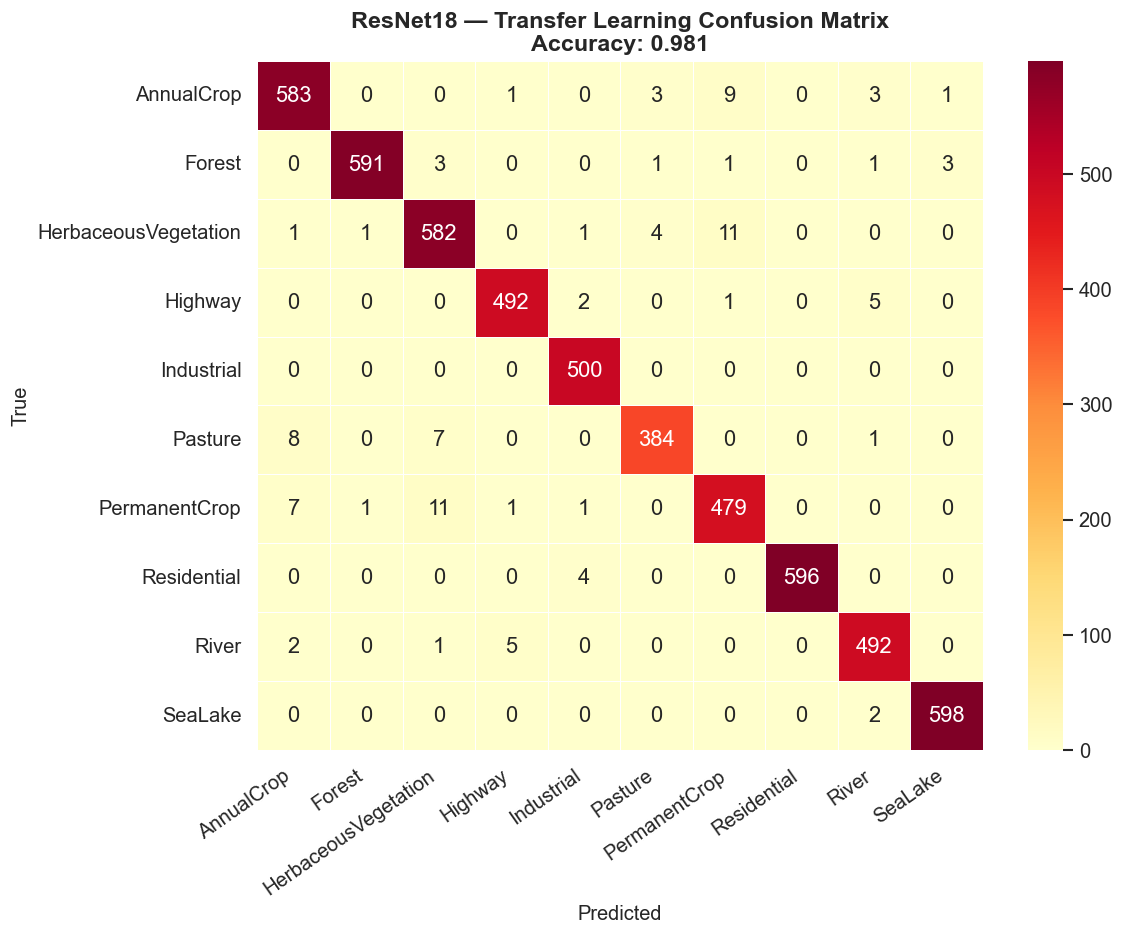

In [24]:
# =============================================================================
# 3.6 Transfer Learning — ResNet18 fine-tuned on EuroSAT
# =============================================================================
# Load a pre-trained ResNet18 and replace the final classification head.
# ResNet18 expects (N, 3, 224, 224) input, so we resize images on-the-fly.

resnet_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet_transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_resnet_dataset = TensorImageDataset(X_rgb_train_tensor, y_train_tensor, transform=resnet_transform_train)
val_resnet_dataset = TensorImageDataset(X_rgb_val_tensor, y_val_tensor, transform=resnet_transform_eval)
test_resnet_dataset = TensorImageDataset(X_rgb_test_tensor, y_test_tensor, transform=resnet_transform_eval)

train_resnet_loader = DataLoader(train_resnet_dataset, batch_size=32, shuffle=True)
val_resnet_loader = DataLoader(val_resnet_dataset, batch_size=32, shuffle=False)
test_resnet_loader = DataLoader(test_resnet_dataset, batch_size=32, shuffle=False)

print("Preparing ResNet datasets with on-the-fly transforms...")
print(f"ResNet train samples : {len(train_resnet_dataset)}")
print(f"ResNet val samples   : {len(val_resnet_dataset)}")
print(f"ResNet sample shape  : {train_resnet_dataset[0][0].shape}")

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

print(f"\nResNet18 Parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"Trainable params  : {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}")

print("\nTraining ResNet18 (Transfer Learning)...")
resnet_history = train_model(
    resnet,
    train_resnet_loader,
    val_resnet_loader,
    epochs=15,
    lr=1e-4,
    model_name="ResNet18",
)
plot_training_history(resnet_history, "ResNet18 — Transfer Learning")

resnet_preds, resnet_labels, resnet_acc = evaluate_model(
    resnet,
    test_resnet_loader,
    class_names,
    split_name="Test",
)
plot_confusion_matrix_dl(resnet_labels, resnet_preds, class_names, "ResNet18 — Transfer Learning", resnet_acc)


## 3.7 Multispectral Analysis 

Loading 13-band multispectral TIFF files...


Loading MS TIFFs: 100%|██████████| 27000/27000 [00:32<00:00, 833.79it/s]


Multispectral array shape: (27000, 13, 64, 64)
Value range (raw): [0, 28003]

Per-band means (before norm): [1353.7286   1117.2059   1041.8867    946.5523   1199.1858   2003.0063
 2374.0137   2301.2292    732.17993    12.099526 1820.6937   1118.2045
 2599.7817  ]
Per-band stds  (before norm): [ 245.29155    333.44077    395.2197     594.4786     567.0134
  861.0199    1086.9731    1118.32       403.8443       4.7293878
 1002.5953     760.62476   1231.68     ]

Multispectral train tensor: torch.Size([16200, 13, 64, 64]) (13 Sentinel-2 bands)

Multispectral CNN Parameters: 2,196,554

Training Multispectral CNN (13-band)...
  Epoch   1/30 | Train Loss: 1.2681 Acc: 0.5738 | Val Loss: 0.6232 Acc: 0.7893
  Epoch   5/30 | Train Loss: 0.6669 Acc: 0.7736 | Val Loss: 0.3620 Acc: 0.8933
  Epoch  10/30 | Train Loss: 0.5243 Acc: 0.8304 | Val Loss: 0.2794 Acc: 0.9131
  Epoch  15/30 | Train Loss: 0.4245 Acc: 0.8666 | Val Loss: 0.2492 Acc: 0.9241
  Epoch  20/30 | Train Loss: 0.3831 Acc: 0.8816 | Val L

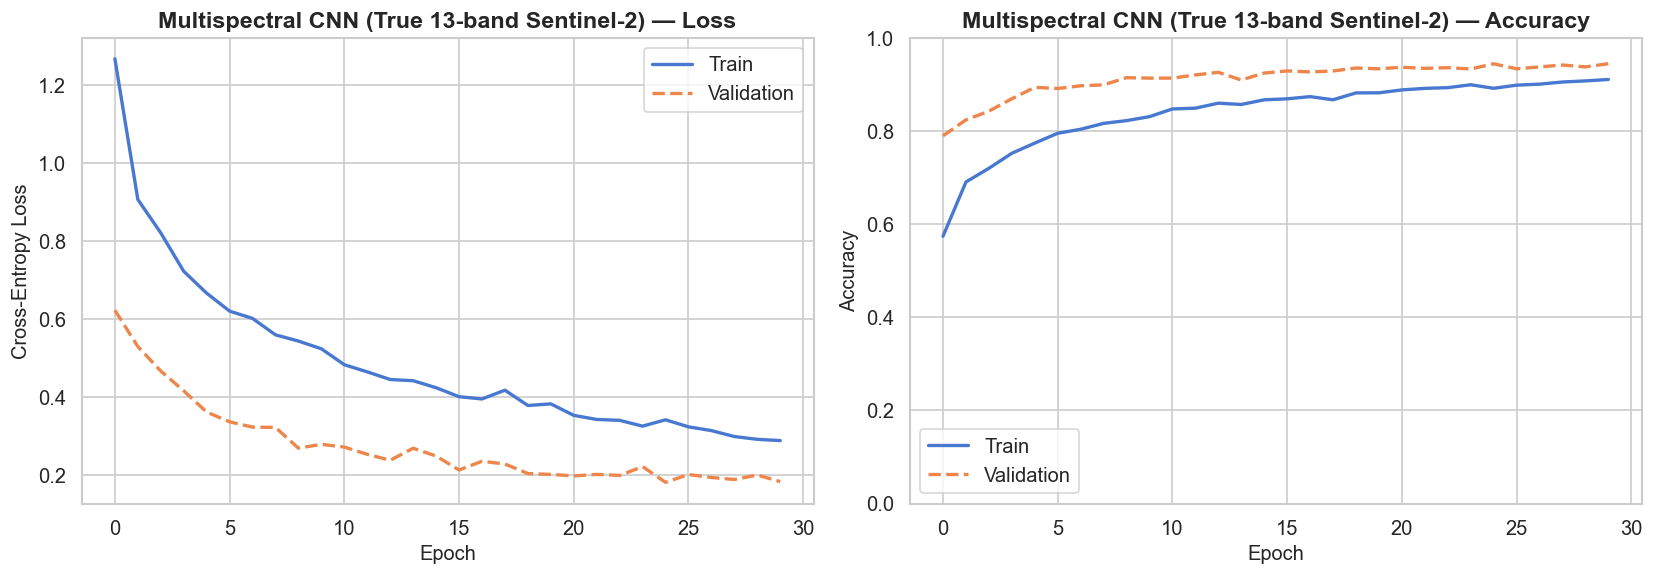


Test Accuracy: 0.9452
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.91      0.93       600
              Forest       0.98      0.98      0.98       600
HerbaceousVegetation       0.91      0.92      0.92       600
             Highway       0.97      0.91      0.94       500
          Industrial       0.97      0.92      0.94       500
             Pasture       0.93      0.91      0.92       400
       PermanentCrop       0.87      0.92      0.90       500
         Residential       0.92      0.97      0.94       600
               River       0.97      0.98      0.97       500
             SeaLake       0.99      1.00      0.99       600

            accuracy                           0.95      5400
           macro avg       0.95      0.94      0.94      5400
        weighted avg       0.95      0.95      0.95      5400



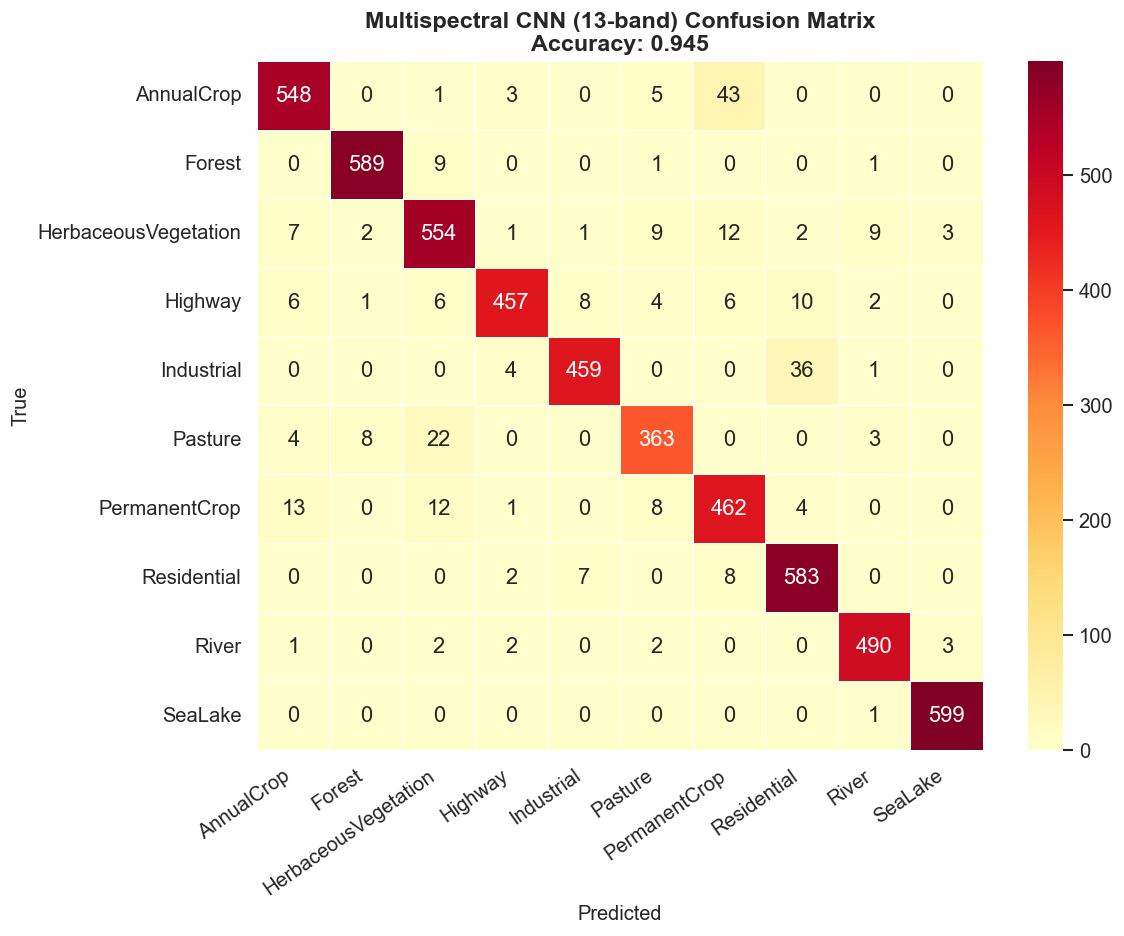

In [ ]:
# =============================================================================
# 3.7 Multispectral CNN (True 13-band Sentinel-2)
# =============================================================================


import rasterio
from pathlib import Path

MS_DIR = Path("data/EuroSAT_MS")

# RGB files:  AnnualCrop/AnnualCrop_1.jpg
# MS files:   AnnualCrop/AnnualCrop_1.tif
ms_images = []

print("Loading 13-band multispectral TIFF files...")
for rgb_path, label in tqdm(full_dataset.samples, desc="Loading MS TIFFs"):
    # Derive the corresponding TIFF path
    rgb_path = Path(rgb_path)
    class_name = rgb_path.parent.name
    stem = rgb_path.stem  # e.g. "AnnualCrop_1"
    tif_path = MS_DIR / class_name / f"{stem}.tif"

    if not tif_path.exists():
        raise FileNotFoundError(f"Missing MS TIFF: {tif_path}")

    with rasterio.open(tif_path) as src:
        # src.read() returns (bands, height, width)
        img = src.read().astype(np.float32)  # (13, 64, 64)
    ms_images.append(img)

ms_images = np.stack(ms_images)  # (N, 13, 64, 64)
print(f"Multispectral array shape: {ms_images.shape}")
print(f"Value range (raw): [{ms_images.min():.0f}, {ms_images.max():.0f}]")

# --- Per-band z-score normalization ---
# Compute mean and std per band across all samples
band_means = ms_images.mean(axis=(0, 2, 3), keepdims=True)  # (1, 13, 1, 1)
band_stds = ms_images.std(axis=(0, 2, 3), keepdims=True) + 1e-6
ms_normalized = (ms_images - band_means) / band_stds

print(f"\nPer-band means (before norm): {band_means.squeeze()}")
print(f"Per-band stds  (before norm): {band_stds.squeeze()}")

# --- Split using same indices as RGB ---
X_ms_train = torch.tensor(ms_normalized[idx_train], dtype=torch.float32)
X_ms_val = torch.tensor(ms_normalized[idx_val], dtype=torch.float32)
X_ms_test = torch.tensor(ms_normalized[idx_test], dtype=torch.float32)

train_ms_loader = DataLoader(
    TensorDataset(X_ms_train, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_ms_loader = DataLoader(
    TensorDataset(X_ms_val, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_ms_loader = DataLoader(
    TensorDataset(X_ms_test, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
print(f"\nMultispectral train tensor: {X_ms_train.shape} (13 Sentinel-2 bands)")


class MultispectralCNN(nn.Module):
    def __init__(self, in_channels=13, num_classes=10, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


ms_model = MultispectralCNN()
print(f"\nMultispectral CNN Parameters: {sum(p.numel() for p in ms_model.parameters()):,}")

print("\nTraining Multispectral CNN (13-band)...")
ms_history = train_model(
    ms_model,
    train_ms_loader,
    val_ms_loader,
    epochs=30,
    lr=1e-3,
    model_name="MS-CNN-13band",
)
plot_training_history(ms_history, "Multispectral CNN (True 13-band Sentinel-2)")

ms_preds, ms_labels, ms_acc = evaluate_model(ms_model, test_ms_loader, class_names, split_name="Test")
plot_confusion_matrix_dl(ms_labels, ms_preds, class_names, "Multispectral CNN (13-band)", ms_acc)

---

# 4. Analysis & Reflection

## 4.1 Comprehensive Model Comparison


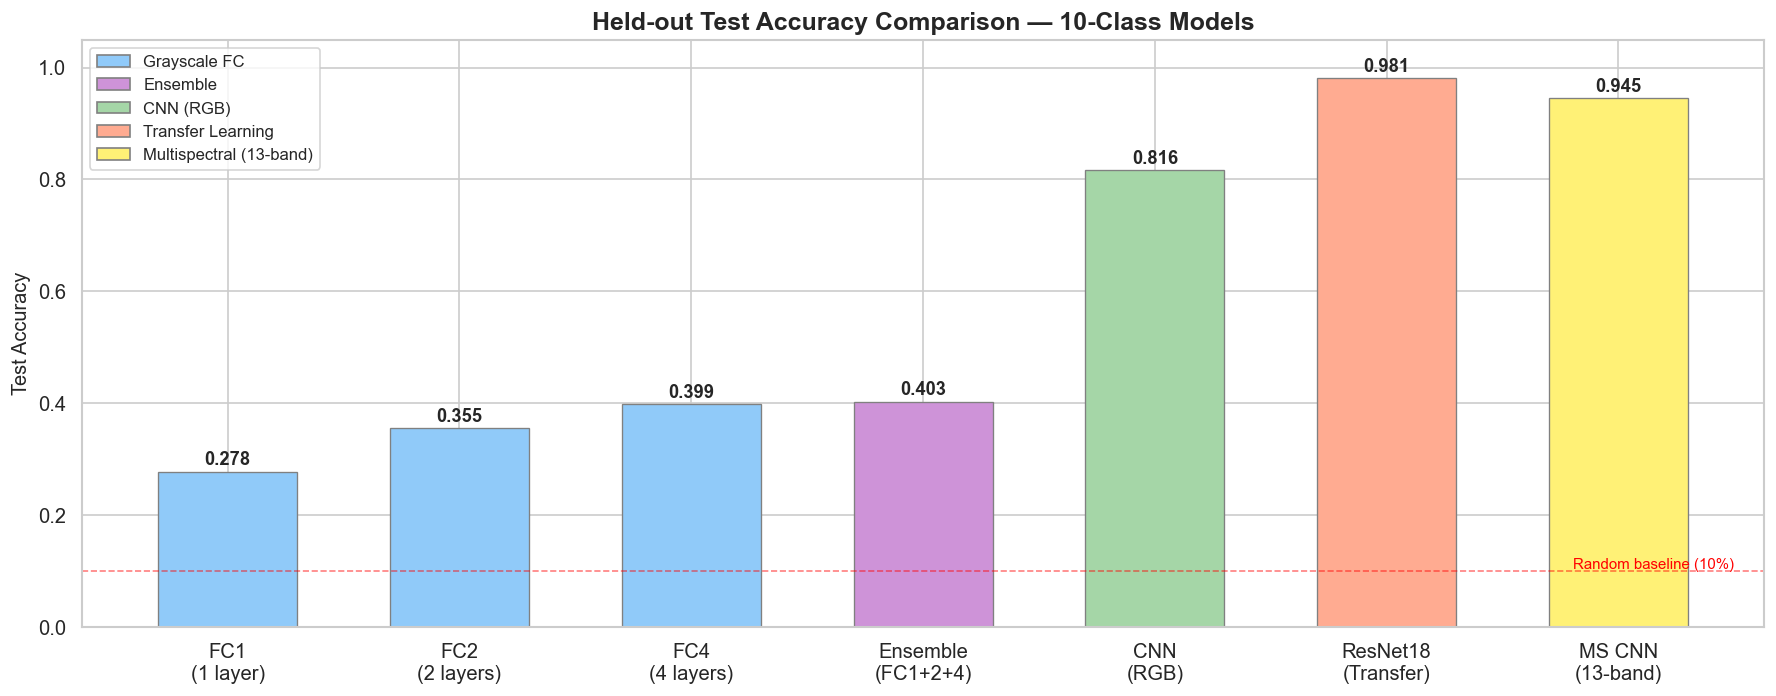

In [27]:
# =============================================================================
# 4.1 Model Accuracy Comparison Chart
# =============================================================================
# Compare the 10-class deep learning models on held-out test accuracy.
# Validation performance is used during training; the numbers below are final
# test-set evaluations after model selection.

dl_models = {
    "FC1\n(1 layer)": fc1_acc,
    "FC2\n(2 layers)": fc2_acc,
    "FC4\n(4 layers)": fc4_acc,
    "Ensemble\n(FC1+2+4)": ensemble_acc,
    "CNN\n(RGB)": cnn_acc,
    "ResNet18\n(Transfer)": resnet_acc,
    "MS CNN\n(13-band)": ms_acc,
}

fig, ax = plt.subplots(figsize=(15, 6))

names = list(dl_models.keys())
accs = list(dl_models.values())

family_colors = [
    "#90CAF9", "#90CAF9", "#90CAF9",
    "#CE93D8",
    "#A5D6A7",
    "#FFAB91",
    "#FFF176",
]

bars = ax.bar(names, accs, color=family_colors, edgecolor="gray", linewidth=0.8, width=0.6)

for bar, acc_val in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.5, lw=1)
ax.text(len(names) - 0.5, 0.105, "Random baseline (10%)", ha="right", color="red", fontsize=9)

ax.set_title("Held-out Test Accuracy Comparison — 10-Class Models", fontsize=15, fontweight="bold")
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_ylim(0, 1.05)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#90CAF9", edgecolor="gray", label="Grayscale FC"),
    Patch(facecolor="#CE93D8", edgecolor="gray", label="Ensemble"),
    Patch(facecolor="#A5D6A7", edgecolor="gray", label="CNN (RGB)"),
    Patch(facecolor="#FFAB91", edgecolor="gray", label="Transfer Learning"),
    Patch(facecolor="#FFF176", edgecolor="gray", label="Multispectral (13-band)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

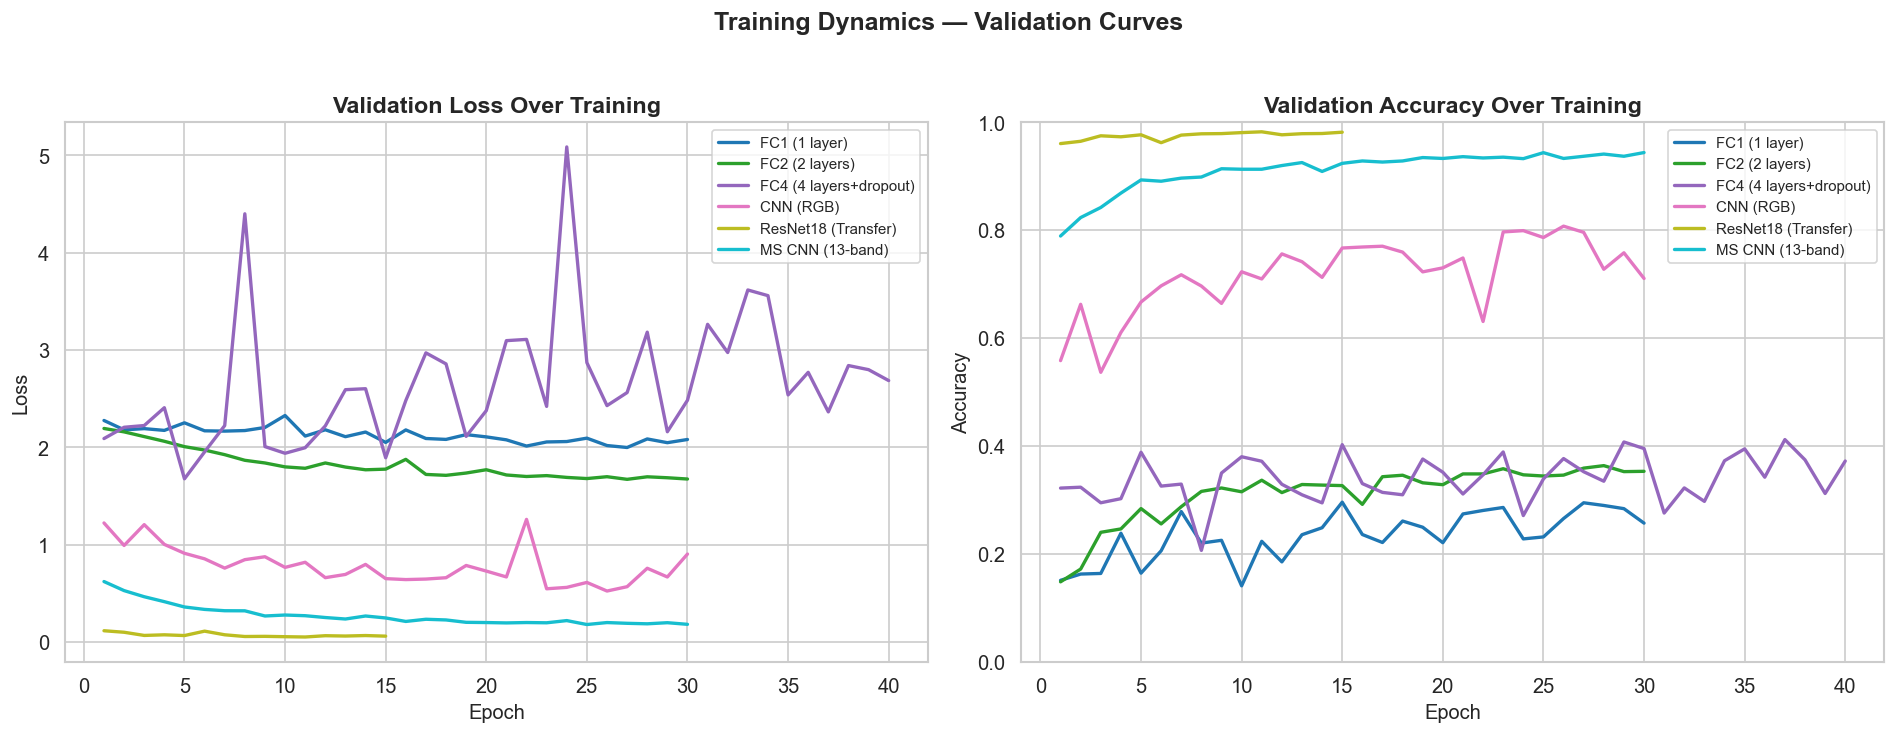

In [28]:
# =============================================================================
# 4.1b Training Dynamics Comparison
# =============================================================================
# Overlay validation curves for all DL models to compare convergence and
# overfitting behavior without repeatedly peeking at the test set.

all_histories = {
    "FC1 (1 layer)": fc1_history,
    "FC2 (2 layers)": fc2_history,
    "FC4 (4 layers+dropout)": fc4_history,
    "CNN (RGB)": cnn_history,
    "ResNet18 (Transfer)": resnet_history,
    "MS CNN (13-band)": ms_history,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_hist = plt.cm.tab10(np.linspace(0, 1, len(all_histories)))

for (name, hist), color in zip(all_histories.items(), colors_hist):
    epochs = range(1, len(hist["val_acc"]) + 1)
    axes[0].plot(epochs, hist["val_loss"], label=name, lw=2, color=color)
    axes[1].plot(epochs, hist["val_acc"], label=name, lw=2, color=color)

axes[0].set_title("Validation Loss Over Training", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)

axes[1].set_title("Validation Accuracy Over Training", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, 1])

plt.suptitle("Training Dynamics — Validation Curves", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.2 Key Insights & Discussion

### Evaluation Protocol

We used a 60/20/20 stratified split for our train, validation and test data so that we could ensure that each class was represented evenly across all splits. The validation set was used during training in order to monitor performance and to select the best-performing model, and the test set was only used at the end to determine the final accuracy.

### Traditional ML vs. Deep Learning

**Traditional ML (SVM, Random Forest):**

The traditional machine learning methods we used, SVM and Random Forest, operate on flattened grayscale pixel values, which meant that they ignored the spatial structure of the images. Despite this limitation, the models performed well on the simpler 3-class subset, especially in the classes that were visually distinct (e.g. forest vs. industrial). These were also much faster to train as they require less computational power. However, the model's performance dropped when we scaled up to the full 10-classes. The reason for the drop in performance is mainly because the problem becomes more complex and includes more visually similar categories. Since traditional models ignore spatial structure and treat images as flat vectors, they struggle to distinguish between classes that differ in subtle patterns or textures, which becomes more important in the full 10-class setting.


**Deep Learning (FC, CNN, ResNet):**

The fully connected (FC) models provide a useful baseline but are limited because they treat each pixel independently and do not account for spatial relationships. The CNN significantly improved the models performance by learning local features such as edges, textures, and shapes through convolutional filters. The best-performing model was ResNet18, mainly because it used transfer learning from ImageNet. This means it already knew how to detect basic features like edges and textures, so it could adapt more easily to satellite images and achieve better accuracy.


### Multispectral Analysis

 In the final section, we used the true multispectral EuroSAT dataset, which included more than just RGB channels. These additional spectral bands, especially near-infrared (NIR), provide valuable information about vegetation health, moisture, and surface composition that is not visible in standard RGB images. By incorporating these extra channels, the model could better differentiate between classes that may appear similar in RGB, leading to improved classification performance. This result should be seen more as a feature-engineering baseline rather than proof of how useful real NIR or SWIR bands are.


### Interpreting ErrorsThe

Using the confusion matrices and classification reports, we could identify the main failure cases on the test set. The most noticeable errors occurred  between Residential and Industrial, as well as vegetation classes like AnnualCrop, PermanentCrop, and HerbaceousVegetation. These classes tend to look similar, which makes them harder for the model to distinguish. However, the confusion matrix provides the most reliable way to confirm which classes are actually being misclassified, rather than relying only on intuition. While some classes seem similar based on visualisation, the confusion matrix shows the exact patterns of errors across all predictions, making it clear which class pairs are most frequently confused. 


## 4.3 Future Directions

1. **Better use of multi-spectral data**: 
Instead of using all spectral bands equally, future work could focus on selecting the most informative bands, such as including NIR and relevant SWIR bands, which are particularly useful for distinguishing vegetation and moisture differences. Additionally, incorporating indices like NDVI could better highlight differences 
between vegetation classes such as AnnualCrop, PermanentCrop, and HerbaceousVegetation, which were frequently confused in our results.
2. **Validation-aware tuning**: 
Most models were trained with fixed hyperparameters. Performance could likely be improved by tuning the learning rate, augmentation strength, and regularization more carefully using the validation set.
3. **Better remote-sensing pretraining**: 
While ImageNet pretraining worked well, it is based on natural images. Using models pretrained on satellite imagery (e.g. SatMAE) could lead to better feature representations.
4. **Deeper error analysis**: 
Further analysis of the confusion matrix could help identify the most frequent misclassifications (e.g. Residential vs. Industrial). Understanding these errors more deeply could guide targeted improvements, such as class-specific augmentation or feature engineering.

In [29]:
# =============================================================================
# 4.3 Final Summary Table
# =============================================================================
# Print a comprehensive summary of all model results.

import pandas as pd

summary_data = {
    "Model": [
        "SVM (Majority Vote)*", "Random Forest*",
        "FC1 (1 layer)", "FC2 (2 layers)", "FC4 (4 layers+dropout)",
        "Ensemble (FC1+2+4)", "CNN (RGB)", "ResNet18 (Transfer)",
        "MS CNN (13-band)",
    ],
    "Input": [
        "Gray flat", "Gray flat",
        "Gray flat", "Gray flat", "Gray flat",
        "Gray flat", "RGB 64x64", "RGB 224x224",
        "Sentinel-2 13-band 64x64",
    ],
    "Classes": [
        3, 3, 10, 10, 10, 10, 10, 10, 10,
    ],
    "Test Accuracy": [
        svm_multi_acc, rf_acc,
        fc1_acc, fc2_acc, fc4_acc,
        ensemble_acc, cnn_acc, resnet_acc, ms_acc,
    ],
    "Category": [
        "Traditional ML", "Traditional ML",
        "Deep Learning", "Deep Learning", "Deep Learning",
        "Deep Learning", "Deep Learning", "Deep Learning",
        "Deep Learning",
    ],
}

df_summary = pd.DataFrame(summary_data)
df_summary["Test Accuracy"] = df_summary["Test Accuracy"].map("{:.4f}".format)

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(df_summary.to_string(index=False))
print("\n* 3-class models (Forest/Industrial/Residential only — not directly comparable)")
print("* Deep learning models use validation metrics for training/model selection and report test accuracy once.")
print("* MS CNN uses true Sentinel-2 13-band multispectral data with per-band z-score normalization.")
print("=" * 80)

FINAL MODEL COMPARISON
                 Model                    Input  Classes Test Accuracy       Category
  SVM (Majority Vote)*                Gray flat        3        0.7976 Traditional ML
        Random Forest*                Gray flat        3        0.9088 Traditional ML
         FC1 (1 layer)                Gray flat       10        0.2776  Deep Learning
        FC2 (2 layers)                Gray flat       10        0.3552  Deep Learning
FC4 (4 layers+dropout)                Gray flat       10        0.3989  Deep Learning
    Ensemble (FC1+2+4)                Gray flat       10        0.4030  Deep Learning
             CNN (RGB)                RGB 64x64       10        0.8165  Deep Learning
   ResNet18 (Transfer)              RGB 224x224       10        0.9809  Deep Learning
      MS CNN (13-band) Sentinel-2 13-band 64x64       10        0.9452  Deep Learning

* 3-class models (Forest/Industrial/Residential only — not directly comparable)
* Deep learning models use validatio

In [ ]:
# =============================================================================
# Inspect the most frequent test-set confusion pairs
# =============================================================================

def top_confusions(y_true, y_pred, class_names, top_k=5):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)

    pairs = []
    for i, true_name in enumerate(class_names):
        for j, pred_name in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], true_name, pred_name))

    return sorted(pairs, reverse=True)[:top_k]


print("Top test-set confusions for ResNet18:")
for count, true_name, pred_name in top_confusions(resnet_labels, resnet_preds, class_names, top_k=5):
    print(f"  {true_name:>22} -> {pred_name:<22} : {count}")


Top test-set confusions for ResNet18:
           PermanentCrop -> HerbaceousVegetation   : 11
    HerbaceousVegetation -> PermanentCrop          : 11
              AnnualCrop -> PermanentCrop          : 9
                 Pasture -> AnnualCrop             : 8
           PermanentCrop -> AnnualCrop             : 7
